# Adversarial Forecasting: A GAN-Based Framework for Time-Series Imputation and Weather Prediction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Melvin0163/Adversarial-Forecasting-A-GAN-Based-Framework-for-Time-Series-Imputation-and-Weather-Prediction/blob/main/Adversarial_Forecasting_GAN.ipynb)

**Study site:** Chennai, India (13.08° N, 80.23° E) · **Data:** ERA5-Land daily reanalysis, 1950–2025, six surface variables · **Target:** 2 m air temperature · **Framework:** TensorFlow / Keras

Weather records have gaps (sensor faults, transmission loss, maintenance), and most forecasting methods need gap-free input. This notebook applies generative adversarial networks (GANs) to two related tasks on daily weather data:

1. **Imputation**: reconstructing values removed from a multivariate record, both isolated days and multi-day gaps.
2. **Forecasting**: predicting the next 7 days of temperature from the recent past.

Three adversarial models are compared against simple baselines on the same held-out *future* period (every test date is later than every training date):

| Model | Generator | Adversary | Tasks |
|---|---|---|---|
| **A. Shared GAN** | Shared BiLSTM masked-sequence generator | GAIN-style point-wise discriminator (binary cross-entropy) | imputation, and forecasting by masking the last 7 days |
| **B. Shared WGAN-GP** | Same shared generator architecture | Block-level Wasserstein critic with gradient penalty | imputation, and forecasting by masking the last 7 days |
| **C. Simple GAN** | One network per task | C1: GAIN-style discriminator · C2: conditional discriminator | C1 imputation only · C2 forecasting only |

"Shared" means two things. Models A and B use the **same generator architecture**, so any difference between them comes from the adversarial objective (binary cross-entropy vs. Wasserstein distance). And each trained generator is **shared across both tasks**: it fills interior gaps, and it forecasts when the last days of a window are masked. The Simple GAN is the task-specific counterpart, with a dedicated network for each task.

**Pipeline:** Earth Engine extraction → chronological split and train-only scaling → synthetic missingness (random + block-wise) with a missing-value indicator → 30-day blocks → adversarial training with validation checkpointing → evaluation on the held-out test period against linear-interpolation and persistence baselines, averaged over several seeds.

**Main results** (real data, test period 2014–2025, mean over 3 seeds): the conditional forecasting GAN beats persistence at every lead day (RMSE over the 7-day horizon 0.93 vs. 1.12 °C), also when the input history has gaps. None of the GAN imputers beats linear interpolation (temperature RMSE 0.90–0.97 vs. 0.67 °C); Section 11 explains why and what to change.

**How to run:** open the notebook in Colab (badge above), choose *Runtime → Change runtime type → T4 GPU* (optional: the run shown here took 55 minutes on a 4-core CPU), then *Runtime → Run all*. The data are loaded from the repository, so no Earth Engine account is needed. Set `QUICK_TEST = True` in Section 0 for a fast end-to-end check.

**Contents**
0. Setup and configuration
1. Data extraction: ERA5-Land via Google Earth Engine
2. Exploratory data analysis
3. Missing-data benchmark and chronological split
4. Model architectures and objectives
5. Model A: Shared GAN
6. Model B: Shared WGAN-GP
7. Model C: Simple GAN (C1 imputation, C2 forecasting)
8. Evaluation: imputation
9. Evaluation: forecasting
10. Results summary
11. Discussion and limitations
12. Reproducibility and references

## 0. Setup and configuration

Runs on Google Colab or locally (see `requirements.txt`). A GPU is optional: the run shown here (3 seeds) took 55 minutes on a 4-core CPU. All settings live in the configuration cell below. The model hyperparameters are the ones used in the original experiments.

In [1]:
import json
import os
import platform
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # hide TensorFlow's C++ info messages
import tensorflow as tf
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Model, layers

NOTEBOOK_START = time.time()
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)

gpus = tf.config.list_physical_devices("GPU")
print(f"Python {platform.python_version()} | TensorFlow {tf.__version__} | NumPy {np.__version__} | "
      f"pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print("GPU:", ", ".join(g.name for g in gpus) if gpus else "none found, training will run on the CPU (slow)")

Python 3.11.15 | TensorFlow 2.21.0 | NumPy 2.4.6 | pandas 3.0.6 | scikit-learn 1.9.1
GPU: none found, training will run on the CPU (slow)


In [2]:
# ------------------------------------------------------------------ run control
QUICK_TEST = False        # True: 2 epochs and 1 seed, to check that everything runs (the numbers are not meaningful)
SEEDS = [42, 43, 44]      # model seeds; test metrics are reported as mean ± std over these runs
MASK_SEED = 42            # seed of the synthetic missingness, fixed so that every model sees identical gaps

# ------------------------------------------------------------------ variables
FEATURES = ["temp", "surface_pressure", "total_precipitation_sum",
            "dewpoint_temperature_2m", "u_component_of_wind_10m", "v_component_of_wind_10m"]
TARGET = "temp"                        # 2 m air temperature (°C), the variable that is reported and forecast
T_IDX = FEATURES.index(TARGET)
N_FEATURES = len(FEATURES)

# ------------------------------------------------------------------ benchmark design
BLOCK_LEN = 30                         # length of the non-overlapping blocks, in days
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15      # chronological split over blocks; the final 15 % is the test period
MISSINGNESS = dict(random_frac=0.10,   # share of days removed at random, per variable
                   block_frac=0.10,    # share of days removed as contiguous runs, per variable
                   block_len_range=(3, 10))
HORIZON = 7                            # forecast lead time, in days

# ------------------------------------------------------------------ hyperparameters (as in the original experiments)
HP_SHARED_GAN = dict(epochs=100, batch_size=128, g_lr=1e-3, d_lr=1e-3, recon_weight=100.0)
HP_SHARED_WGAN = dict(epochs=100, batch_size=128, g_lr=1e-4, c_lr=1e-4, recon_weight=100.0,
                      n_critic=5, gp_weight=10.0)
HP_SIMPLE_IMP = dict(epochs=100, batch_size=128, g_lr=1e-3, d_lr=1e-3, recon_weight=100.0)
HP_SIMPLE_FC = dict(context=30, noise_dim=16, epochs=60, batch_size=128, lr=1e-3, recon_weight=100.0)

if QUICK_TEST:
    SEEDS = SEEDS[:1]
    for hp in (HP_SHARED_GAN, HP_SHARED_WGAN, HP_SIMPLE_IMP, HP_SIMPLE_FC):
        hp["epochs"] = 2

# ------------------------------------------------------------------ folders
DATA_DIR, OUT_DIR = Path("data"), Path("outputs")
FIG_DIR, MODEL_DIR = OUT_DIR / "figures", OUT_DIR / "models"
for folder in (DATA_DIR, FIG_DIR, MODEL_DIR):
    folder.mkdir(parents=True, exist_ok=True)

In [3]:
# Each model keeps one colour in every figure (colour-blind-safe categorical order); grey marks the naive baselines.
COLORS = {
    "Shared GAN (A)": "#2a78d6",           # blue
    "Shared WGAN-GP (B)": "#eb6834",       # orange
    "Simple GAN (C1)": "#1baf7a",          # aqua
    "Simple GAN (C2)": "#1baf7a",
    "Simple GAN (C1 → C2)": "#1baf7a",
    "Linear interpolation": "#898781",     # grey
    "Persistence": "#898781",
}
MARKERS = {"Shared GAN (A)": "o", "Shared WGAN-GP (B)": "s", "Simple GAN (C1)": "^", "Simple GAN (C2)": "^",
           "Simple GAN (C1 → C2)": "^", "Linear interpolation": "D", "Persistence": "D"}
INK, INK_2, AXIS, GRID, WASH = "#0b0b0b", "#52514e", "#c3c2b7", "#e1e0d9", "#f0efec"
BLUE, BLUE_LIGHT, BLUE_DARK = "#2a78d6", "#9ec5f4", "#1c5cab"   # single-series plots

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 200, "savefig.bbox": "tight", "figure.facecolor": "white",
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.titlelocation": "left",
    "axes.labelsize": 10, "axes.labelcolor": INK_2,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.6, "lines.markersize": 6,
    "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
})


def legend_right(ax, **kwargs):
    """Legend outside the plotting area, so it never covers data."""
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), **kwargs)


def save_fig(fig, name):
    """Write outputs/figures/<name>.png at 200 dpi and show the figure inline."""
    fig.savefig(FIG_DIR / f"{name}.png")
    plt.show()

## 1. Data extraction: ERA5-Land via Google Earth Engine

The data are the **ERA5-Land daily aggregates** (`ECMWF/ERA5_LAND/DAILY_AGGR`; Muñoz-Sabater et al., 2021), read at the grid cell that contains Chennai (80.23° E, 13.08° N). ERA5-Land is a ~9 km land reanalysis forced by ERA5, so the series has no gaps. That is what makes a controlled benchmark possible: we remove values ourselves and score the reconstructions against the truth (Section 3).

| Column | ERA5-Land band | Unit | Daily statistic |
|---|---|---|---|
| `temp` | `temperature_2m` | °C (converted from K) | mean; **target variable** |
| `surface_pressure` | `surface_pressure` | Pa | mean |
| `total_precipitation_sum` | `total_precipitation_sum` | m | total |
| `dewpoint_temperature_2m` | `dewpoint_temperature_2m` | K | mean |
| `u_component_of_wind_10m` | `u_component_of_wind_10m` | m s⁻¹ | mean (eastward) |
| `v_component_of_wind_10m` | `v_component_of_wind_10m` | m s⁻¹ | mean (northward) |

**Access.** The extract used in this study is published with the repository as `data/era5_chennai_1950_2025.csv`. The cell below takes the first source that is available:

1. the local file `data/era5_chennai_1950_2025.csv` (present when the repository is cloned);
2. the copy in the GitHub repository, downloaded automatically (for example when the notebook is opened in Colab from the badge);
3. a fresh pull from Earth Engine with `extract_era5_land()`, the code that produced the published extract. This needs a Google Cloud project with the Earth Engine API enabled: set `GEE_PROJECT` and approve the authentication prompt. The pull takes a few minutes.

In [4]:
GEE_PROJECT = "your-gee-project-id"   # <-- only needed to re-extract the data from Earth Engine
LON, LAT = 80.23, 13.08                # Chennai
START_DATE, END_DATE = "1950-01-01", "2025-12-31"
ERA5_BANDS = ["temperature_2m", "surface_pressure", "total_precipitation_sum",
              "dewpoint_temperature_2m", "u_component_of_wind_10m", "v_component_of_wind_10m"]
DATA_CSV = DATA_DIR / "era5_chennai_1950_2025.csv"
DATA_URL = ("https://raw.githubusercontent.com/Melvin0163/Adversarial-Forecasting-A-GAN-Based-Framework-for-"
            "Time-Series-Imputation-and-Weather-Prediction/main/data/era5_chennai_1950_2025.csv")


def extract_era5_land(project, lon, lat, start, end):
    """Download the daily ERA5-Land aggregates at one point from Google Earth Engine."""
    if project == "your-gee-project-id":
        raise ValueError("Set GEE_PROJECT to your Earth Engine-enabled Google Cloud project, "
                         f"or place the extracted CSV at {DATA_CSV}.")
    try:
        import ee
        import geemap
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "earthengine-api", "geemap"])
        import ee
        import geemap

    ee.Authenticate()
    ee.Initialize(project=project)

    point = ee.Geometry.Point([lon, lat])
    era5 = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
            .filterDate(start, end)
            .select(ERA5_BANDS))

    def to_feature(image):
        values = image.reduceRegion(ee.Reducer.first(), point, 1000)
        return ee.Feature(None, values.set("time", image.date().millis()))

    raw = geemap.ee_to_df(ee.FeatureCollection(era5.map(to_feature)))   # a few minutes for ~76 years
    raw["date"] = pd.to_datetime(raw["time"], unit="ms")
    raw["temp"] = raw["temperature_2m"] - 273.15                         # Kelvin -> Celsius
    return raw.sort_values("date").reset_index(drop=True)[["date"] + FEATURES]


# Data source, in order: local copy -> copy published in the repository -> fresh Earth Engine extraction
if DATA_CSV.exists():
    source = f"local copy {DATA_CSV}"
else:
    try:
        pd.read_csv(DATA_URL).to_csv(DATA_CSV, index=False)
        source = f"repository copy {DATA_URL}"
    except OSError as err:
        print(f"Repository copy not reachable ({err}); extracting from Earth Engine instead")
        extract_era5_land(GEE_PROJECT, LON, LAT, START_DATE, END_DATE).to_csv(DATA_CSV, index=False)
        source = "Google Earth Engine"
df = pd.read_csv(DATA_CSV, parse_dates=["date"])
print(f"Data loaded from the {source}")

Data loaded from the local copy data/era5_chennai_1950_2025.csv


In [5]:
# One row per calendar day, in time order. ERA5-Land is gap-free at land points, so the repair branch
# below should never run; it keeps the notebook usable with other data sources.
df = df[["date"] + FEATURES].drop_duplicates("date").sort_values("date").set_index("date")
df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq="D")).rename_axis("date")
n_missing_raw = int(df[FEATURES].isna().sum().sum())
if n_missing_raw:
    print(f"WARNING: {n_missing_raw} missing raw values, filled by linear interpolation before scaling")
    df[FEATURES] = df[FEATURES].interpolate(limit_direction="both")
df = df.reset_index()

print(f"{len(df):,} daily records from {df['date'].min():%Y-%m-%d} to {df['date'].max():%Y-%m-%d}; "
      f"missing raw values: {n_missing_raw}")
display(df.head())
display(df[FEATURES].describe().T)

27,757 daily records from 1950-01-02 to 2025-12-30; missing raw values: 0


,date,temp,surface_pressure,total_precipitation_sum,dewpoint_temperature_2m,u_component_of_wind_10m,v_component_of_wind_10m
0,1950-01-02,23.8611,100777.6287,8.6783e-07,289.2652,-0.7925,1.2048
1,1950-01-03,23.9046,100887.6696,4.3511e-07,290.4860,-1.2053,1.2260
2,1950-01-04,24.2368,101059.2926,1.0177e-05,290.8517,-2.2296,-0.2174
3,1950-01-05,24.5105,101213.0573,1.9446e-05,290.5438,-3.0726,-1.4472
4,1950-01-06,24.6863,101146.2290,5.5134e-07,289.8103,-2.8486,-2.6349


,count,mean,std,min,25%,50%,75%,max
temp,27757.0,27.8096,2.7101,2.0477e+01,2.5426e+01,27.9604,29.9478,36.1245
surface_pressure,27757.0,100669.7291,382.7895,9.9268e+04,1.0035e+05,100646.7645,100994.1219,101632.4002
total_precipitation_sum,27757.0,0.0027,0.0073,-2.5932e-08,9.2500e-06,0.0002,0.0021,0.2255
dewpoint_temperature_2m,27757.0,295.0416,2.1055,2.8595e+02,2.9361e+02,295.4439,296.7187,299.7633
u_component_of_wind_10m,27757.0,-0.0043,1.7591,-7.2504e+00,-1.3942e+00,-0.3300,1.2836,7.8074
v_component_of_wind_10m,27757.0,0.6565,2.1158,-7.4636e+00,-9.7168e-01,1.1376,2.2000,8.9818


## 2. Exploratory data analysis

The first figure shows the six daily series with a 365-day running mean. The second puts temperature in climate context: the annual mean with a linear trend, and the number of hot days per year in each decade. A hot day is one whose daily mean temperature exceeds the 95th percentile of the WMO 1961–1990 reference period, and the counts are normalised per year so the partial 2020s decade is comparable. A trend matters for the modelling: the chronological test period is the most recent part of the record, so any warming shifts it away from the training distribution.

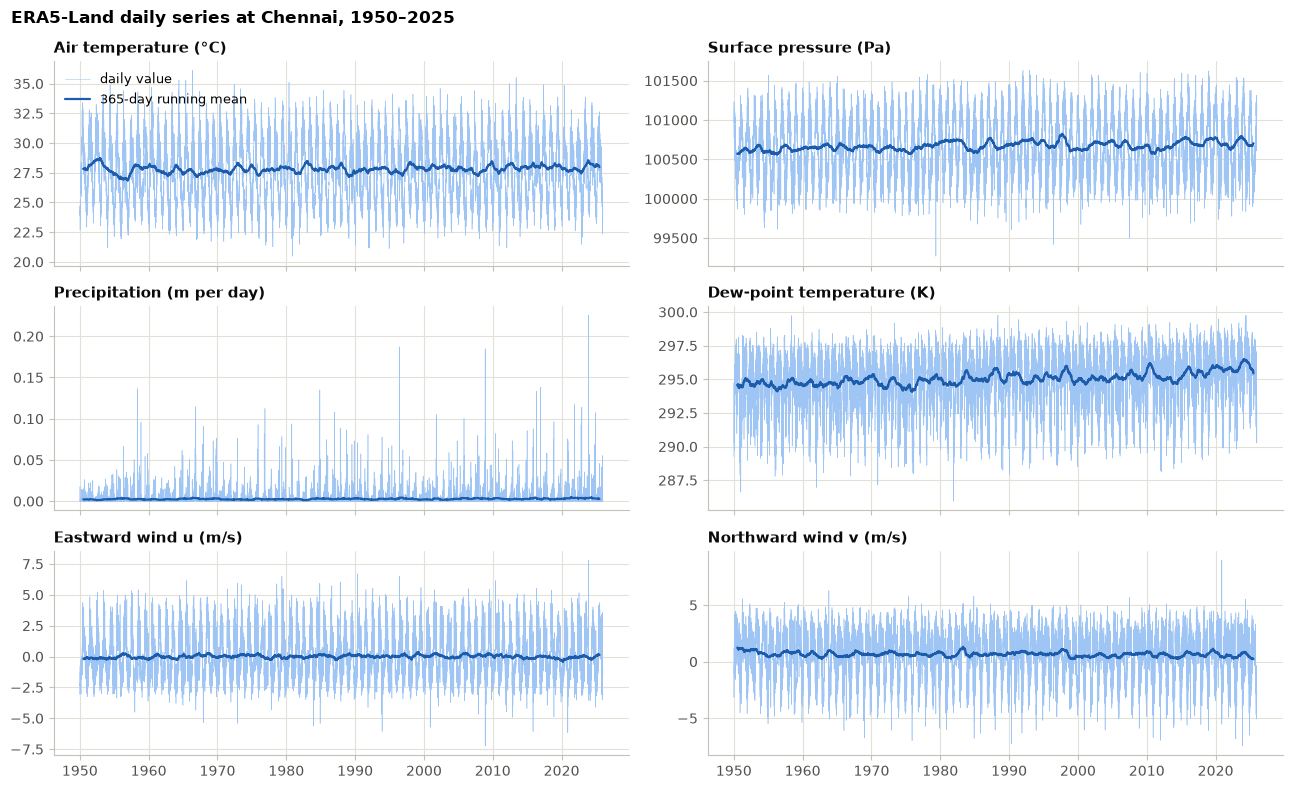

In [6]:
LABELS = {
    "temp": "Air temperature (°C)",
    "surface_pressure": "Surface pressure (Pa)",
    "total_precipitation_sum": "Precipitation (m per day)",
    "dewpoint_temperature_2m": "Dew-point temperature (K)",
    "u_component_of_wind_10m": "Eastward wind u (m/s)",
    "v_component_of_wind_10m": "Northward wind v (m/s)",
}
daily = df.set_index("date")[FEATURES]
running_mean = daily.rolling(365, center=True, min_periods=365).mean()

fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharex=True)
for ax, col in zip(axes.flat, FEATURES):
    ax.plot(daily.index, daily[col], color=BLUE_LIGHT, lw=0.4, label="daily value")
    ax.plot(running_mean.index, running_mean[col], color=BLUE_DARK, lw=1.6, label="365-day running mean")
    ax.set_title(LABELS[col])
axes[0, 0].legend(loc="upper left")
fig.suptitle(f"ERA5-Land daily series at Chennai, {daily.index.min():%Y}–{daily.index.max():%Y}",
             fontweight="bold", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "01_variables_overview")

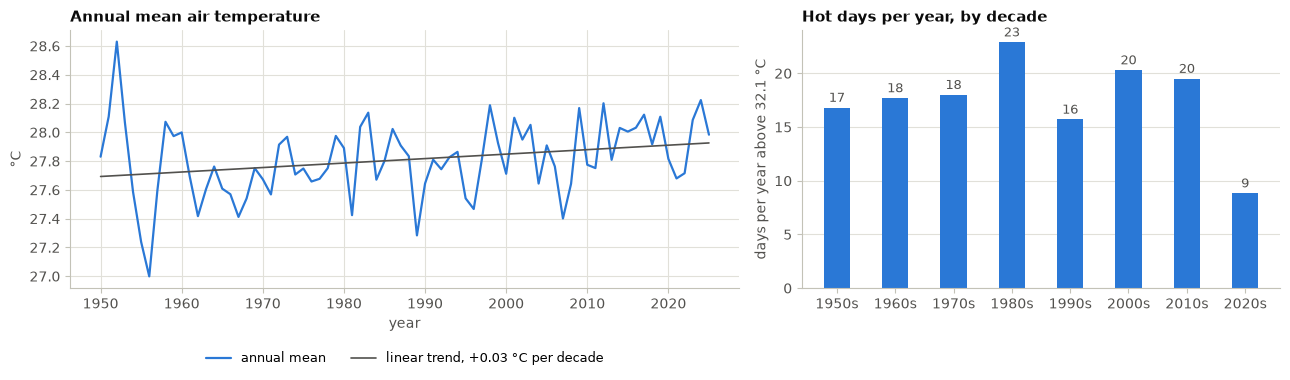

Hot-day threshold (95th percentile of 1961–1990 daily mean temperature): 32.13 °C; trend: +0.031 °C per decade


In [7]:
temp = df.set_index("date")["temp"]
days_per_year = temp.groupby(temp.index.year).size()
annual_temp = temp.groupby(temp.index.year).mean()[days_per_year >= 360]        # complete years only
slope, intercept = np.polyfit(annual_temp.index, annual_temp.values, 1)

hot_threshold = float(np.percentile(temp["1961":"1990"], 95))                   # WMO reference period
decade = (temp.index.year // 10) * 10
hot_days_per_year = (temp > hot_threshold).groupby(decade).sum() / (temp.groupby(decade).size() / 365.25)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1.4, 1]})
ax1.plot(annual_temp.index, annual_temp.values, color=BLUE, label="annual mean")
ax1.plot(annual_temp.index, intercept + slope * annual_temp.index, color=INK_2, lw=1.2,
         label=f"linear trend, {10 * slope:+.2f} °C per decade")
ax1.set(title="Annual mean air temperature", xlabel="year", ylabel="°C")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
bars = ax2.bar([f"{d}s" for d in hot_days_per_year.index], hot_days_per_year.values, width=0.45, color=BLUE)
ax2.bar_label(bars, fmt="%.0f", padding=2, color=INK_2, fontsize=9)
ax2.set(title="Hot days per year, by decade", ylabel=f"days per year above {hot_threshold:.1f} °C")
ax2.grid(axis="x", visible=False)
fig.tight_layout()
save_fig(fig, "02_temperature_trend_hot_days")
print(f"Hot-day threshold (95th percentile of 1961–1990 daily mean temperature): {hot_threshold:.2f} °C; "
      f"trend: {10 * slope:+.3f} °C per decade")

## 3. Missing-data benchmark and chronological split

ERA5-Land has no gaps, so gaps are created on purpose and the removed values are kept as ground truth. The benchmark is built in four steps:

1. **Chronological split.** The daily series is cut into non-overlapping 30-day blocks. The first 70 % of blocks are used for training, the next 15 % for checkpoint selection (validation), and the final 15 % are the untouched **test period**. Splitting in time rather than at random keeps future information out of training.
2. **Standardisation.** Every variable is z-scored with the mean and standard deviation of the training rows only.
3. **Synthetic missingness** (fixed seed, identical for every model). For each variable independently, 10 % of days are removed at random (missing completely at random) and about 10 % more are removed as contiguous runs of 3–10 days, like an instrument outage. Overlaps bring the total to about 18.5 % of all values.
4. **Model input.** Removed entries are zero-filled (0 is the training mean after scaling), and a **missing-value indicator** $M$ (1 = missing, 0 = observed) is appended. Each 30-day block becomes a $30 \times 12$ input $[\tilde X \mid M]$.

In [8]:
def inject_missing(n_rows, n_cols, rng, random_frac=0.10, block_frac=0.10, block_len_range=(3, 10)):
    """Boolean mask (True = removed): random single days plus contiguous runs, drawn independently per variable."""
    miss = np.zeros((n_rows, n_cols), dtype=bool)
    for c in range(n_cols):
        miss[rng.choice(n_rows, size=int(n_rows * random_frac), replace=False), c] = True   # random days
        placed, guard = 0, 0
        while placed < int(n_rows * block_frac) and guard < 2000:                          # block gaps
            guard += 1
            run = rng.integers(block_len_range[0], block_len_range[1] + 1)
            start = rng.integers(0, max(1, n_rows - run))
            end = min(n_rows, start + run)
            miss[start:end, c] = True
            placed += end - start
    return miss


# 1) chronological split over non-overlapping 30-day blocks
n_rows = len(df)
n_blocks = n_rows // BLOCK_LEN
n_train_blocks, n_val_blocks = int(n_blocks * TRAIN_FRAC), int(n_blocks * VAL_FRAC)
block_ids = {
    "train": np.arange(0, n_train_blocks),
    "val": np.arange(n_train_blocks, n_train_blocks + n_val_blocks),
    "test": np.arange(n_train_blocks + n_val_blocks, n_blocks),
}
train_end = n_train_blocks * BLOCK_LEN                     # first row of the validation period
val_end = (n_train_blocks + n_val_blocks) * BLOCK_LEN      # first row of the test period

# 2) z-scores with statistics from the training rows only
scaler = StandardScaler().fit(df[FEATURES].iloc[:train_end])
scaled = scaler.transform(df[FEATURES]).astype(np.float32)
TEMP_MEAN, TEMP_STD = float(scaler.mean_[T_IDX]), float(scaler.scale_[T_IDX])

# 3) synthetic missingness over the whole record; the removed values stay available as ground truth
miss = inject_missing(n_rows, N_FEATURES, np.random.default_rng(MASK_SEED), **MISSINGNESS)

# 4) blocks of [zero-filled values | missing-value indicator] -> model input of shape (blocks, 30, 12)
n_used = n_blocks * BLOCK_LEN
true_blocks = scaled[:n_used].reshape(n_blocks, BLOCK_LEN, N_FEATURES)
mask_blocks = miss[:n_used].reshape(n_blocks, BLOCK_LEN, N_FEATURES).astype(np.float32)   # 1 = missing
input_blocks = np.concatenate([true_blocks * (1.0 - mask_blocks), mask_blocks], axis=-1)

imp_data = {split: {"x": input_blocks[ids], "y": true_blocks[ids]} for split, ids in block_ids.items()}
print(f"Injected missing rate: {miss.mean():.1%} of all values | {n_blocks} blocks of {BLOCK_LEN} days "
      f"({n_rows - n_used} trailing days fall after the last full block) | model input {input_blocks.shape}")

Injected missing rate: 18.5% of all values | 925 blocks of 30 days (7 trailing days fall after the last full block) | model input (925, 30, 12)


In [9]:
def period_of(first_row, last_row):
    return f"{df['date'].iloc[first_row]:%Y-%m-%d} to {df['date'].iloc[last_row]:%Y-%m-%d}"


split_table = pd.DataFrame({
    split: {"blocks": len(ids),
            "days": len(ids) * BLOCK_LEN,
            "period": period_of(ids[0] * BLOCK_LEN, (ids[-1] + 1) * BLOCK_LEN - 1),
            "removed, all variables": f"{mask_blocks[ids].mean():.1%}",
            "removed, temperature": f"{mask_blocks[ids][..., T_IDX].mean():.1%}"}
    for split, ids in block_ids.items()}).T
display(split_table)

# The missing-value indicator matrix next to the gappy data (first days of the record)
indicator = pd.DataFrame(miss.astype(int), columns=[f"{c}_missing" for c in FEATURES])
display(pd.concat([df[["date"]], df[FEATURES].mask(miss), indicator], axis=1).head(10))

,blocks,days,period,"removed, all variables","removed, temperature"
train,647,19410,1950-01-02 to 2003-02-22,18.5%,18.4%
val,138,4140,2003-02-23 to 2014-06-24,19.2%,21.4%
test,140,4200,2014-06-25 to 2025-12-23,17.8%,16.7%


,date,temp,surface_pressure,total_precipitation_sum,dewpoint_temperature_2m,u_component_of_wind_10m,v_component_of_wind_10m,temp_missing,surface_pressure_missing,total_precipitation_sum_missing,dewpoint_temperature_2m_missing,u_component_of_wind_10m_missing,v_component_of_wind_10m_missing
0,1950-01-02,23.8611,NaN,8.6783e-07,289.2652,-0.7925,NaN,0,1,0,0,0,1
1,1950-01-03,23.9046,100887.6696,4.3511e-07,290.4860,-1.2053,1.2260,0,0,0,0,0,0
2,1950-01-04,24.2368,101059.2926,1.0177e-05,290.8517,-2.2296,-0.2174,0,0,0,0,0,0
3,1950-01-05,24.5105,101213.0573,1.9446e-05,290.5438,-3.0726,-1.4472,0,0,0,0,0,0
4,1950-01-06,24.6863,101146.2290,5.5134e-07,289.8103,-2.8486,-2.6349,0,0,0,0,0,0
5,1950-01-07,24.1799,101132.8335,3.4972e-04,290.4650,-1.9040,-3.1489,0,0,0,0,0,0
6,1950-01-08,23.9696,101191.3646,2.6990e-03,293.4086,-2.3985,-2.5519,0,0,0,0,0,0
7,1950-01-09,23.4830,101188.1828,8.3263e-03,294.0767,-2.1107,-2.5884,0,0,0,0,0,0
8,1950-01-10,23.4525,101234.8298,1.7854e-02,NaN,-3.0379,NaN,0,0,0,1,0,1
9,1950-01-11,24.1718,101208.7809,1.9880e-03,294.4321,-2.1979,-1.7213,0,0,0,0,0,0


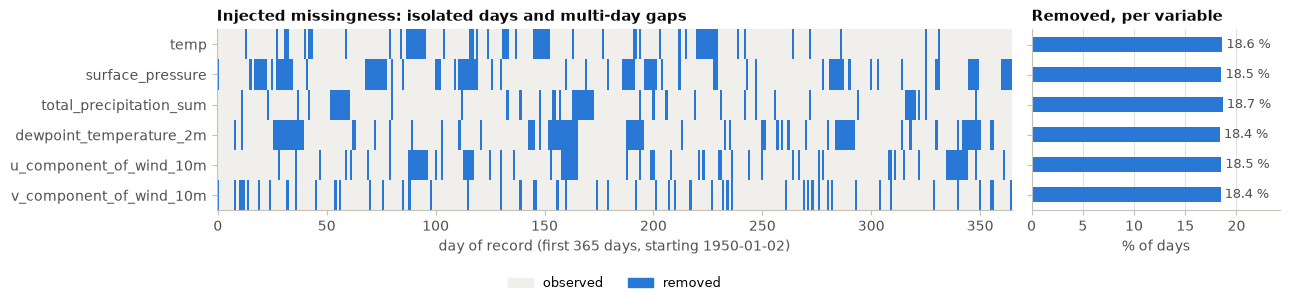

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={"width_ratios": [3.2, 1]})
ax1.imshow(miss[:365].T, aspect="auto", interpolation="nearest", cmap=ListedColormap([WASH, BLUE]))
ax1.set_yticks(range(N_FEATURES), FEATURES)
ax1.set_xlabel(f"day of record (first 365 days, starting {df['date'].iloc[0]:%Y-%m-%d})")
ax1.set_title("Injected missingness: isolated days and multi-day gaps")
ax1.grid(False)
ax1.legend(handles=[Patch(color=WASH, label="observed"), Patch(color=BLUE, label="removed")],
           loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2)

rates = 100 * miss.mean(axis=0)
bars = ax2.barh(range(N_FEATURES), rates, height=0.5, color=BLUE)
ax2.set_yticks(range(N_FEATURES), [""] * N_FEATURES)
ax2.invert_yaxis()
ax2.bar_label(bars, fmt="%.1f %%", padding=3, color=INK_2, fontsize=9)
ax2.set_xlim(0, rates.max() * 1.3)
ax2.set(title="Removed, per variable", xlabel="% of days")
ax2.grid(axis="y", visible=False)
fig.tight_layout()
save_fig(fig, "03_missingness")

## 4. Model architectures and objectives

**Notation.** A block has true values $X \in \mathbb{R}^{30\times 6}$ and indicator $M$ (1 = missing). The generator sees the zero-filled values $\tilde X = (1-M)\odot X$ together with $M$ and returns $\bar X = G(\tilde X, M)$. The imputed block keeps every observed value and uses the generator only where data are missing:

$$\hat X = (1-M)\odot \tilde X + M \odot \bar X$$

**Shared generator $G$ (Models A, B and C1).** Two bidirectional LSTM layers (64 units per direction), then a time-distributed Dense(64, ReLU) layer and a time-distributed Dense(6) output. Because the layers are bidirectional, every missing day can draw on context before and after it.

**Model A: Shared GAN (GAIN-style, Yoon et al., 2018).** A point-wise discriminator $D$ (BiLSTM(48) → Dense(48, ReLU) → Dense(6, sigmoid)) receives $\hat X$ together with the observation mask as its *hint*. For every day and variable it outputs the probability that the value was observed rather than generated:

$$\mathcal{L}_D = -\mathbb{E}\left[(1-M)\odot\log D(\hat X) + M\odot\log\left(1-D(\hat X)\right)\right]$$

$$\mathcal{L}_G = -\mathbb{E}\left[M\odot\log D(\hat X)\right] + \alpha \frac{\sum (1-M)\odot(\tilde X-\bar X)^2}{\sum (1-M)}, \qquad \alpha = 100$$

The first generator term rewards imputations that the discriminator takes for observed values. The second is the reconstruction error on the observed entries.

**Model B: Shared WGAN-GP (Arjovsky et al., 2017; Gulrajani et al., 2017).** The generator is the same. The adversary is a critic $C$ (BiLSTM(48) → BiLSTM(24) → Dense(48, ReLU) → Dense(1), no sigmoid) that gives a whole 30-day block a single realism score. The critic estimates the Wasserstein-1 distance between complete training blocks $X$ and imputed blocks $\hat X$. A gradient penalty on random interpolates $\check X = \epsilon X + (1-\epsilon)\hat X$, with $\epsilon \sim U[0,1]$, keeps it approximately 1-Lipschitz:

$$\mathcal{L}_C = \mathbb{E}\left[C(\hat X)\right] - \mathbb{E}\left[C(X)\right] + \lambda \mathbb{E}\left[\left(\lVert \nabla_{\check X} C(\check X) \rVert_2 - 1\right)^2\right], \qquad \lambda = 10$$

$$\mathcal{L}_G = -\mathbb{E}\left[C(\hat X)\right] + \alpha \frac{\sum (1-M)\odot(\tilde X-\bar X)^2}{\sum (1-M)}$$

**Model C: Simple GAN (task-specific).**
* **C1, imputation:** the same GAIN-style formulation as Model A, built as a standalone imputer. It uses the standard LSTM kernels (cuDNN on a GPU), and its checkpoints are selected on the target variable, temperature.
* **C2, forecasting:** a conditional GAN (Mirza & Osindero, 2014). The generator $G_f$ (LSTM(64) → LSTM(64), concatenated with noise $z \in \mathbb{R}^{16}$, → Dense(64, ReLU) → Dense(7)) maps a 30-day context $c$ of all six variables to the next 7 days of temperature. The discriminator $D_f$ encodes $c$ and a 7-day temperature path $y$ with one LSTM(48) each, then applies Dense(48, ReLU) → Dense(1, sigmoid). At inference $z = 0$, which gives a deterministic point forecast.

$$\mathcal{L}_{D_f} = \mathrm{BCE}\left(1, D_f(c, y)\right) + \mathrm{BCE}\left(0, D_f(c, \hat y)\right), \qquad \mathcal{L}_{G_f} = \mathrm{BCE}\left(1, D_f(c, \hat y)\right) + \beta \lVert y - \hat y \rVert_2^2, \qquad \beta = 100$$

**Checkpointing.** Each model keeps the weights of its best validation epoch. Models A and B are selected on all-variable imputation RMSE, C1 on temperature imputation RMSE, and C2 on forecast RMSE. The test period is never used for any decision.

**Why `unroll=True`.** The gradient penalty needs second-order gradients through the critic, which the fused cuDNN LSTM kernel does not provide. Unrolled LSTMs compute the same function and support double back-propagation. The shared generator is unrolled as well, so Models A and B train exactly the same network.

In [11]:
def build_generator(units=64, unroll=True):
    """Masked-sequence generator: [zero-filled values | indicator] (30 x 12) -> reconstruction (30 x 6)."""
    inp = layers.Input(shape=(BLOCK_LEN, 2 * N_FEATURES))
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True, unroll=unroll))(inp)
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True, unroll=unroll))(x)
    x = layers.TimeDistributed(layers.Dense(units, activation="relu"))(x)
    out = layers.TimeDistributed(layers.Dense(N_FEATURES))(x)
    return Model(inp, out, name="generator")


def build_gain_discriminator(units=48, unroll=True):
    """Point-wise discriminator: [imputed block | hint] -> P(entry was observed) for every day and variable."""
    inp = layers.Input(shape=(BLOCK_LEN, 2 * N_FEATURES))
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True, unroll=unroll))(inp)
    x = layers.TimeDistributed(layers.Dense(units, activation="relu"))(x)
    out = layers.TimeDistributed(layers.Dense(N_FEATURES, activation="sigmoid"))(x)
    return Model(inp, out, name="discriminator")


def build_wgan_critic(units=48):
    """Block-level critic: complete or imputed block (30 x 6) -> unbounded realism score."""
    inp = layers.Input(shape=(BLOCK_LEN, N_FEATURES))
    x = layers.Bidirectional(layers.LSTM(units, return_sequences=True, unroll=True))(inp)
    x = layers.Bidirectional(layers.LSTM(units // 2, unroll=True))(x)
    x = layers.Dense(units, activation="relu")(x)
    out = layers.Dense(1)(x)
    return Model(inp, out, name="critic")


def build_forecast_generator(context, noise_dim, units=64):
    """Conditional generator: (context of all variables, noise z) -> next HORIZON days of temperature."""
    x_in, z_in = layers.Input((context, N_FEATURES)), layers.Input((noise_dim,))
    h = layers.LSTM(units, return_sequences=True)(x_in)
    h = layers.LSTM(units)(h)
    h = layers.Dense(units, activation="relu")(layers.Concatenate()([h, z_in]))
    out = layers.Reshape((HORIZON, 1))(layers.Dense(HORIZON)(h))
    return Model([x_in, z_in], out, name="forecast_generator")


def build_forecast_discriminator(context, units=48):
    """Conditional discriminator: (context, 7-day temperature path) -> P(path is real)."""
    x_in, y_in = layers.Input((context, N_FEATURES)), layers.Input((HORIZON, 1))
    h = layers.Concatenate()([layers.LSTM(units)(x_in), layers.LSTM(units)(y_in)])
    out = layers.Dense(1, activation="sigmoid")(layers.Dense(units, activation="relu")(h))
    return Model([x_in, y_in], out, name="forecast_discriminator")


networks = {
    "Generator G (A, B, C1)": build_generator(),
    "Discriminator D (A, C1)": build_gain_discriminator(),
    "Critic C (B)": build_wgan_critic(),
    "Forecast generator G_f (C2)": build_forecast_generator(HP_SIMPLE_FC["context"], HP_SIMPLE_FC["noise_dim"]),
    "Forecast discriminator D_f (C2)": build_forecast_discriminator(HP_SIMPLE_FC["context"]),
}
display(pd.DataFrame({"trainable parameters": {name: f"{net.count_params():,}" for name, net in networks.items()}}))
del networks

,trainable parameters
"Generator G (A, B, C1)","146,886"
"Discriminator D (A, C1)","28,374"
Critic C (B),"46,753"
Forecast generator G_f (C2),"56,839"
Forecast discriminator D_f (C2),"24,865"


In [12]:
bce = tf.keras.losses.BinaryCrossentropy()


def blend(x_obs, mask, x_gen):
    """Keep the observed values; use the generator output only where mask == 1 (missing)."""
    return x_obs + mask * (x_gen - x_obs)


def impute(G, x_in):
    """Blended reconstruction of [zero-filled values | indicator] blocks with a trained generator."""
    obs, m = x_in[..., :N_FEATURES], x_in[..., N_FEATURES:]
    return obs + m * (G(x_in, training=False).numpy() - obs)


def imputation_scores(x_hat, x_in, y_true):
    """Errors at the artificially removed entries only; observed entries are copied through unchanged."""
    m = x_in[..., N_FEATURES:].astype(bool)
    err_all = (x_hat - y_true)[m]
    m_t = m[..., T_IDX]
    y_t, p_t = y_true[..., T_IDX][m_t], x_hat[..., T_IDX][m_t]
    rmse_t, mae_t = np.sqrt(np.mean((p_t - y_t) ** 2)), np.mean(np.abs(p_t - y_t))
    return {
        "temp_RMSE_degC": rmse_t * TEMP_STD,
        "temp_MAE_degC": mae_t * TEMP_STD,
        "temp_R2": 1.0 - np.sum((p_t - y_t) ** 2) / np.sum((y_t - y_t.mean()) ** 2),
        "temp_RMSE_scaled": rmse_t,
        "all_RMSE_scaled": np.sqrt(np.mean(err_all ** 2)),
        "all_MAE_scaled": np.mean(np.abs(err_all)),
    }


def make_dataset(*arrays, batch_size):
    """Shuffled (every epoch), batched and prefetched tf.data pipeline."""
    return (tf.data.Dataset.from_tensor_slices(arrays)
            .shuffle(len(arrays[0]), reshuffle_each_iteration=True)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))


def fit_with_checkpoint(model, train_step, dataset, val_scores, select_on, epochs, label):
    """Train for `epochs`, score the validation set after every epoch and restore the weights of the
    epoch with the lowest val_scores(model)[select_on]. train_step returns (adversary loss, generator loss)."""
    history = {"adv_loss": [], "g_loss": [], "val": []}
    best, best_weights, best_epoch = np.inf, None, -1
    start = time.time()
    for epoch in range(epochs):
        adv_losses, g_losses = [], []
        for batch in dataset:
            adv_loss, g_loss = train_step(*batch)
            adv_losses.append(float(adv_loss))
            g_losses.append(float(g_loss))
        scores = val_scores(model)
        history["adv_loss"].append(float(np.mean(adv_losses)))
        history["g_loss"].append(float(np.mean(g_losses)))
        history["val"].append(scores)
        if not np.isfinite(history["g_loss"][-1]):
            print(f"[{label}] non-finite loss at epoch {epoch}; stopping this run early")
            break
        if scores[select_on] < best:
            best, best_weights, best_epoch = scores[select_on], model.get_weights(), epoch
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"[{label}] epoch {epoch:3d}  adversary loss {history['adv_loss'][-1]:8.4f}  "
                  f"generator loss {history['g_loss'][-1]:8.4f}  val {select_on} {scores[select_on]:.4f}")
    if best_weights is not None:
        model.set_weights(best_weights)
    history.update(best_epoch=best_epoch, best_val=float(best), select_on=select_on, seconds=time.time() - start)
    print(f"[{label}] restored best epoch {best_epoch} (val {select_on} = {best:.4f}), "
          f"{history['seconds'] / 60:.1f} min")
    return history


runs = {}   # runs[model name][seed] = (trained generator, training history)

## 5. Model A: Shared GAN (GAIN-style discriminator)

Adam (learning rate $10^{-3}$, $\beta_1 = 0.5$) for both networks, batch size 128, 100 epochs, reconstruction weight $\alpha = 100$. Each batch takes one discriminator update followed by one generator update. The checkpoint with the lowest validation all-variable imputation RMSE is kept.

In [13]:
def train_gain_imputer(data, *, seed, epochs, batch_size, g_lr, d_lr, recon_weight,
                       unroll=True, select_on="all_RMSE_scaled", label="GAN"):
    # GAIN-style GAN imputer (Models A and C1): shared generator + point-wise BCE discriminator.
    tf.keras.utils.set_random_seed(seed)
    G = build_generator(unroll=unroll)
    D = build_gain_discriminator(unroll=unroll)
    g_opt = tf.keras.optimizers.Adam(g_lr, beta_1=0.5)
    d_opt = tf.keras.optimizers.Adam(d_lr, beta_1=0.5)

    @tf.function
    def train_step(xb, mb):
        obs = 1.0 - mb                                    # hint = observation mask
        inp = tf.concat([xb, mb], axis=-1)
        with tf.GradientTape() as tape:                   # discriminator: which entries were observed?
            x_hat = blend(xb, mb, G(inp, training=True))
            d_loss = bce(obs, D(tf.concat([x_hat, obs], axis=-1), training=True))
        d_opt.apply_gradients(zip(tape.gradient(d_loss, D.trainable_variables), D.trainable_variables))
        with tf.GradientTape() as tape:                   # generator: fool D and reconstruct the observed entries
            x_bar = G(inp, training=True)
            d_prob = D(tf.concat([blend(xb, mb, x_bar), obs], axis=-1), training=False)
            g_adv = -tf.reduce_mean(mb * tf.math.log(d_prob + 1e-7))
            g_rec = tf.reduce_sum(obs * tf.square(xb - x_bar)) / (tf.reduce_sum(obs) + 1e-7)
            g_loss = g_adv + recon_weight * g_rec
        g_opt.apply_gradients(zip(tape.gradient(g_loss, G.trainable_variables), G.trainable_variables))
        return d_loss, g_loss

    x_tr = data["train"]["x"]
    ds = make_dataset(x_tr[..., :N_FEATURES], x_tr[..., N_FEATURES:], batch_size=batch_size)
    x_va, y_va = data["val"]["x"], data["val"]["y"]
    history = fit_with_checkpoint(G, train_step, ds, lambda g: imputation_scores(impute(g, x_va), x_va, y_va),
                                  select_on, epochs, label)
    return G, history


runs["Shared GAN (A)"] = {seed: train_gain_imputer(imp_data, seed=seed, label=f"Shared GAN / seed {seed}",
                                                   **HP_SHARED_GAN)
                          for seed in SEEDS}

[Shared GAN / seed 42] epoch   0  adversary loss   0.6708  generator loss  74.6634  val all_RMSE_scaled 0.8132


[Shared GAN / seed 42] epoch  10  adversary loss   0.3609  generator loss  12.9602  val all_RMSE_scaled 0.7117


[Shared GAN / seed 42] epoch  20  adversary loss   0.1635  generator loss   8.1252  val all_RMSE_scaled 0.7618


[Shared GAN / seed 42] epoch  30  adversary loss   0.0611  generator loss   5.0499  val all_RMSE_scaled 0.8171


[Shared GAN / seed 42] epoch  40  adversary loss   0.0251  generator loss   3.1773  val all_RMSE_scaled 0.8396


...

[Shared GAN / seed 44] epoch  60  adversary loss   0.0077  generator loss   1.9404  val all_RMSE_scaled 0.9282


[Shared GAN / seed 44] epoch  70  adversary loss   0.0049  generator loss   1.8768  val all_RMSE_scaled 0.9763


[Shared GAN / seed 44] epoch  80  adversary loss   0.0036  generator loss   2.4541  val all_RMSE_scaled 1.0119


[Shared GAN / seed 44] epoch  90  adversary loss   0.0026  generator loss   1.7285  val all_RMSE_scaled 0.9845


[Shared GAN / seed 44] epoch  99  adversary loss   0.0021  generator loss   1.7720  val all_RMSE_scaled 0.9786
[Shared GAN / seed 44] restored best epoch 9 (val all_RMSE_scaled = 0.6955), 2.2 min


## 6. Model B: Shared WGAN-GP (Wasserstein distance + gradient penalty)

The generator architecture, data, reconstruction weight and checkpoint rule are identical to Model A's; only the adversarial objective changes. Following Gulrajani et al. (2017), the critic gets $n_{\text{critic}} = 5$ updates per generator update, both networks use Adam (learning rate $10^{-4}$, $\beta_1 = 0.5$, $\beta_2 = 0.9$), and the gradient-penalty weight is $\lambda = 10$. The critic compares imputed blocks with **complete** training blocks. That is possible because ERA5-Land is gap-free and the missingness is synthetic (see Section 11). The generator is fixed during the critic updates, so each batch is imputed once and reused for all five critic steps.

In [14]:
def gradient_penalty(critic, real, fake):
    """E[(||grad C(x_interp)||_2 - 1)^2] on random interpolates between complete and imputed blocks."""
    eps = tf.random.uniform([tf.shape(real)[0], 1, 1], 0.0, 1.0)
    interp = eps * real + (1.0 - eps) * fake
    with tf.GradientTape() as tape:
        tape.watch(interp)
        score = critic(interp, training=True)
    grads = tape.gradient(score, interp)
    norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2]) + 1e-12)
    return tf.reduce_mean(tf.square(norm - 1.0))


def train_wgan_gp_imputer(data, *, seed, epochs, batch_size, g_lr, c_lr, recon_weight, n_critic, gp_weight,
                          select_on="all_RMSE_scaled", label="WGAN-GP"):
    # Model B: the shared generator trained against a block-level Wasserstein critic with gradient penalty.
    tf.keras.utils.set_random_seed(seed)
    G, C = build_generator(), build_wgan_critic()
    g_opt = tf.keras.optimizers.Adam(g_lr, beta_1=0.5, beta_2=0.9)
    c_opt = tf.keras.optimizers.Adam(c_lr, beta_1=0.5, beta_2=0.9)

    @tf.function
    def fill(xb, mb):
        return blend(xb, mb, G(tf.concat([xb, mb], axis=-1), training=True))

    @tf.function
    def critic_step(x_hat, real):
        with tf.GradientTape() as tape:
            c_loss = (tf.reduce_mean(C(x_hat, training=True)) - tf.reduce_mean(C(real, training=True))
                      + gp_weight * gradient_penalty(C, real, x_hat))
        c_opt.apply_gradients(zip(tape.gradient(c_loss, C.trainable_variables), C.trainable_variables))
        return c_loss

    @tf.function
    def generator_step(xb, mb):
        obs = 1.0 - mb
        with tf.GradientTape() as tape:
            x_bar = G(tf.concat([xb, mb], axis=-1), training=True)
            g_rec = tf.reduce_sum(obs * tf.square(xb - x_bar)) / (tf.reduce_sum(obs) + 1e-7)
            g_loss = -tf.reduce_mean(C(blend(xb, mb, x_bar), training=False)) + recon_weight * g_rec
        g_opt.apply_gradients(zip(tape.gradient(g_loss, G.trainable_variables), G.trainable_variables))
        return g_loss

    def train_step(xb, mb, real):
        x_hat = fill(xb, mb)                              # G does not change during the critic updates
        for _ in range(n_critic):
            c_loss = critic_step(x_hat, real)
        return c_loss, generator_step(xb, mb)

    x_tr, y_tr = data["train"]["x"], data["train"]["y"]
    ds = make_dataset(x_tr[..., :N_FEATURES], x_tr[..., N_FEATURES:], y_tr, batch_size=batch_size)
    x_va, y_va = data["val"]["x"], data["val"]["y"]
    history = fit_with_checkpoint(G, train_step, ds, lambda g: imputation_scores(impute(g, x_va), x_va, y_va),
                                  select_on, epochs, label)
    return G, history


runs["Shared WGAN-GP (B)"] = {seed: train_wgan_gp_imputer(imp_data, seed=seed, label=f"Shared WGAN-GP / seed {seed}",
                                                          **HP_SHARED_WGAN)
                              for seed in SEEDS}

[Shared WGAN-GP / seed 42] epoch   0  adversary loss   8.4986  generator loss  97.3030  val all_RMSE_scaled 1.0368


[Shared WGAN-GP / seed 42] epoch  10  adversary loss   0.0860  generator loss  42.8192  val all_RMSE_scaled 0.7914


[Shared WGAN-GP / seed 42] epoch  20  adversary loss  -0.1268  generator loss  36.0296  val all_RMSE_scaled 0.7284


[Shared WGAN-GP / seed 42] epoch  30  adversary loss  -0.4451  generator loss  25.5151  val all_RMSE_scaled 0.7062


[Shared WGAN-GP / seed 42] epoch  40  adversary loss  -0.6613  generator loss  20.9221  val all_RMSE_scaled 0.7021


...

[Shared WGAN-GP / seed 44] epoch  60  adversary loss  -0.8724  generator loss  11.9170  val all_RMSE_scaled 0.7007


[Shared WGAN-GP / seed 44] epoch  70  adversary loss  -0.8670  generator loss   9.4901  val all_RMSE_scaled 0.7082


[Shared WGAN-GP / seed 44] epoch  80  adversary loss  -0.9433  generator loss   7.8157  val all_RMSE_scaled 0.7085


[Shared WGAN-GP / seed 44] epoch  90  adversary loss  -0.9874  generator loss   6.0724  val all_RMSE_scaled 0.7142


[Shared WGAN-GP / seed 44] epoch  99  adversary loss  -1.0836  generator loss   4.9756  val all_RMSE_scaled 0.7178
[Shared WGAN-GP / seed 44] restored best epoch 53 (val all_RMSE_scaled = 0.6979), 5.8 min


## 7. Model C: Simple GAN (task-specific networks)

The Simple GAN uses a separate adversarial network for each task, which makes it the task-specific counterpart to the shared models.

### 7.1 C1: imputation GAN

Same GAIN-style objective and hyperparameters as Model A, built as a standalone imputer. It uses the standard LSTM kernels (cuDNN on a GPU), and its checkpoint is selected on **temperature** imputation RMSE, because temperature is the variable of interest.

In [15]:
runs["Simple GAN (C1)"] = {seed: train_gain_imputer(imp_data, seed=seed, unroll=False, select_on="temp_RMSE_scaled",
                                                    label=f"Simple GAN C1 / seed {seed}", **HP_SIMPLE_IMP)
                           for seed in SEEDS}

[Simple GAN C1 / seed 42] epoch   0  adversary loss   0.6708  generator loss  74.6634  val temp_RMSE_scaled 0.5177


[Simple GAN C1 / seed 42] epoch  10  adversary loss   0.3609  generator loss  12.9602  val temp_RMSE_scaled 0.3577


[Simple GAN C1 / seed 42] epoch  20  adversary loss   0.1635  generator loss   8.1185  val temp_RMSE_scaled 0.4387


[Simple GAN C1 / seed 42] epoch  30  adversary loss   0.0611  generator loss   5.0110  val temp_RMSE_scaled 0.5047


[Simple GAN C1 / seed 42] epoch  40  adversary loss   0.0251  generator loss   3.0895  val temp_RMSE_scaled 0.5407


...

[Simple GAN C1 / seed 44] epoch  60  adversary loss   0.0077  generator loss   1.9561  val temp_RMSE_scaled 0.5879


[Simple GAN C1 / seed 44] epoch  70  adversary loss   0.0049  generator loss   2.1051  val temp_RMSE_scaled 0.6402


[Simple GAN C1 / seed 44] epoch  80  adversary loss   0.0036  generator loss   1.8132  val temp_RMSE_scaled 0.6900


[Simple GAN C1 / seed 44] epoch  90  adversary loss   0.0026  generator loss   1.8461  val temp_RMSE_scaled 0.7179


[Simple GAN C1 / seed 44] epoch  99  adversary loss   0.0021  generator loss   1.7326  val temp_RMSE_scaled 0.7403
[Simple GAN C1 / seed 44] restored best epoch 9 (val temp_RMSE_scaled = 0.3600), 2.1 min


### 7.2 C2: conditional forecasting GAN

The generator takes the previous 30 days of all six variables and predicts temperature for the next 7 days. Windows are cut inside each period of the same chronological split, so no window straddles a boundary. Training windows advance by one day; validation and test windows advance by seven, so test targets never overlap. Training runs 60 epochs with Adam (learning rate $10^{-3}$, $\beta_1 = 0.5$) and reconstruction weight $\beta = 100$. The checkpoint with the lowest validation RMSE (°C) is kept. Contexts here are complete; forecasting from gappy records is tested in Section 9.

In [16]:
CONTEXT, NOISE_DIM = HP_SIMPLE_FC["context"], HP_SIMPLE_FC["noise_dim"]


def make_forecast_windows(arr, context, stride):
    """(context days of all variables) -> (next HORIZON days of temperature), inside one period."""
    starts = np.arange(0, len(arr) - context - HORIZON + 1, stride)
    X = np.stack([arr[s:s + context] for s in starts])
    Y = np.stack([arr[s + context:s + context + HORIZON, T_IDX] for s in starts])[..., None]
    return X, Y, starts


fc_data = {}
for split, (lo, hi, stride) in {"train": (0, train_end, 1), "val": (train_end, val_end, HORIZON),
                                "test": (val_end, n_rows, HORIZON)}.items():
    X, Y, starts = make_forecast_windows(scaled[lo:hi], CONTEXT, stride)
    fc_data[split] = {"x": X, "y": Y, "target_rows": lo + starts + CONTEXT}   # row of the first forecast day
print("forecast windows (train / val / test):", ", ".join(f"{len(d['x']):,}" for d in fc_data.values()))


def forecast_scores(pred, y):
    """Forecast accuracy in °C over all windows and lead days."""
    p, t = pred[..., 0] * TEMP_STD + TEMP_MEAN, y[..., 0] * TEMP_STD + TEMP_MEAN
    return {"RMSE_degC": np.sqrt(np.mean((p - t) ** 2)),
            "MAE_degC": np.mean(np.abs(p - t)),
            "R2": 1.0 - np.sum((p - t) ** 2) / np.sum((t - t.mean()) ** 2)}


def forecast_with_gan(Gf, X):
    """Deterministic point forecast: noise z = 0."""
    return Gf([X, np.zeros((len(X), NOISE_DIM), np.float32)], training=False).numpy()


def train_forecast_gan(data, *, seed, context, noise_dim, epochs, batch_size, lr, recon_weight, label="C2"):
    """Model C2: conditional GAN forecaster with BCE adversarial loss + weighted MSE."""
    tf.keras.utils.set_random_seed(seed)
    Gf, Df = build_forecast_generator(context, noise_dim), build_forecast_discriminator(context)
    g_opt = tf.keras.optimizers.Adam(lr, beta_1=0.5)
    d_opt = tf.keras.optimizers.Adam(lr, beta_1=0.5)

    @tf.function
    def train_step(xb, yb):
        z = tf.random.normal([tf.shape(xb)[0], noise_dim])
        with tf.GradientTape() as tape:
            y_fake = Gf([xb, z], training=True)
            d_real, d_fake = Df([xb, yb], training=True), Df([xb, y_fake], training=True)
            d_loss = bce(tf.ones_like(d_real), d_real) + bce(tf.zeros_like(d_fake), d_fake)
        d_opt.apply_gradients(zip(tape.gradient(d_loss, Df.trainable_variables), Df.trainable_variables))
        with tf.GradientTape() as tape:
            y_fake = Gf([xb, z], training=True)
            d_fake = Df([xb, y_fake], training=False)
            g_loss = bce(tf.ones_like(d_fake), d_fake) + recon_weight * tf.reduce_mean(tf.square(yb - y_fake))
        g_opt.apply_gradients(zip(tape.gradient(g_loss, Gf.trainable_variables), Gf.trainable_variables))
        return d_loss, g_loss

    ds = make_dataset(data["train"]["x"], data["train"]["y"], batch_size=batch_size)
    x_va, y_va = data["val"]["x"], data["val"]["y"]
    history = fit_with_checkpoint(Gf, train_step, ds, lambda g: forecast_scores(forecast_with_gan(g, x_va), y_va),
                                  "RMSE_degC", epochs, label)
    return Gf, history


runs["Simple GAN (C2)"] = {seed: train_forecast_gan(fc_data, seed=seed, label=f"Simple GAN C2 / seed {seed}",
                                                    **HP_SIMPLE_FC)
                           for seed in SEEDS}

forecast windows (train / val / test): 19,374, 587, 596


[Simple GAN C2 / seed 42] epoch   0  adversary loss   1.3361  generator loss  24.3870  val RMSE_degC 1.1068


[Simple GAN C2 / seed 42] epoch  10  adversary loss   0.9221  generator loss  11.6533  val RMSE_degC 0.9476


[Simple GAN C2 / seed 42] epoch  20  adversary loss   1.0111  generator loss   9.2734  val RMSE_degC 1.0753


[Simple GAN C2 / seed 42] epoch  30  adversary loss   1.0725  generator loss   6.5327  val RMSE_degC 1.1529


...

[Simple GAN C2 / seed 44] epoch  20  adversary loss   1.0511  generator loss   8.9125  val RMSE_degC 1.0705


[Simple GAN C2 / seed 44] epoch  30  adversary loss   1.1148  generator loss   6.2164  val RMSE_degC 1.1519


[Simple GAN C2 / seed 44] epoch  40  adversary loss   1.1392  generator loss   4.7229  val RMSE_degC 1.1829


[Simple GAN C2 / seed 44] epoch  50  adversary loss   1.1577  generator loss   4.1500  val RMSE_degC 1.2063


[Simple GAN C2 / seed 44] epoch  59  adversary loss   1.1753  generator loss   3.8037  val RMSE_degC 1.2131
[Simple GAN C2 / seed 44] restored best epoch 5 (val RMSE_degC = 0.9480), 8.2 min


In [17]:
# Save the trained generators; discriminators and critics are only needed during training.
SLUGS = {"Shared GAN (A)": "shared_gan", "Shared WGAN-GP (B)": "shared_wgan_gp",
         "Simple GAN (C1)": "simple_gan_c1", "Simple GAN (C2)": "simple_gan_c2"}
for name, seeds in runs.items():
    for seed, (model, _) in seeds.items():
        model.save_weights(str(MODEL_DIR / f"{SLUGS[name]}_generator_seed{seed}.weights.h5"))
print(f"Saved {sum(len(s) for s in runs.values())} generator weight files to {MODEL_DIR}/")
print("Training time (min):", {name: round(sum(h["seconds"] for _, h in s.values()) / 60, 1) for name, s in runs.items()})

Saved 12 generator weight files to outputs/models/
Training time (min): {'Shared GAN (A)': 6.7, 'Shared WGAN-GP (B)': 17.5, 'Simple GAN (C1)': 6.2, 'Simple GAN (C2)': 24.3}


## 8. Evaluation: imputation

### 8.1 Training dynamics

Validation error after every epoch. Lines show the mean over seeds; shaded bands (when there are several seeds) span the minimum and maximum across seeds. Dots mark the checkpoint each run kept, chosen with that model's own selection metric. The adversary losses in the second figure show how the discriminator or critic evolved; the two objectives are on different scales, so each model gets its own panel.

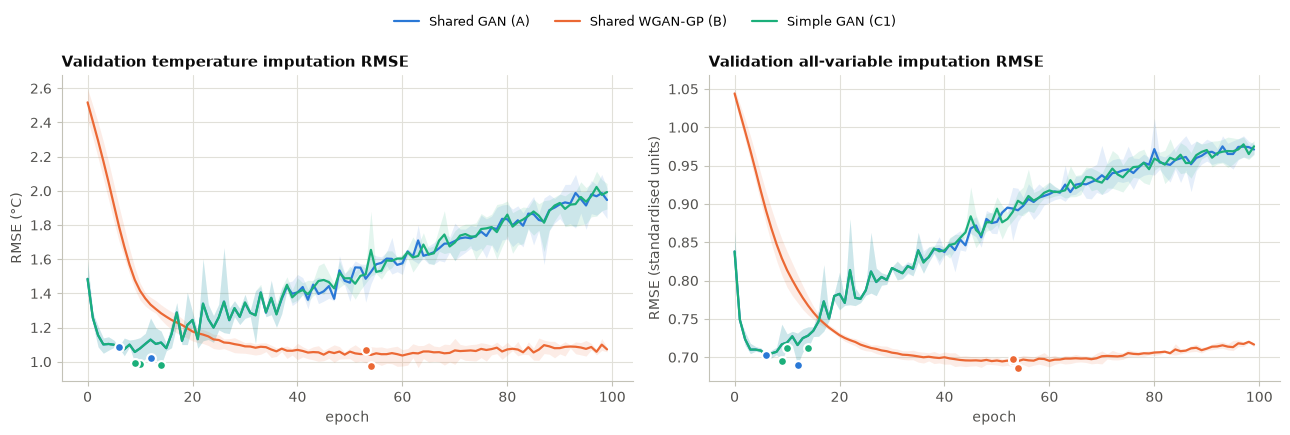

In [18]:
IMPUTERS = ["Shared GAN (A)", "Shared WGAN-GP (B)", "Simple GAN (C1)"]


def val_curves(histories, key):
    """A per-epoch validation metric for every seed of a model -> array (seeds, epochs)."""
    n_epochs = min(len(h["val"]) for h in histories)
    return np.array([[h["val"][e][key] for e in range(n_epochs)] for h in histories])


def plot_band(ax, curves, color, label=None):
    epochs = np.arange(curves.shape[1])
    ax.plot(epochs, curves.mean(axis=0), color=color, label=label)
    if len(curves) > 1:
        ax.fill_between(epochs, curves.min(axis=0), curves.max(axis=0), color=color, alpha=0.12, lw=0)


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
panels = [("temp_RMSE_degC", "Validation temperature imputation RMSE", "RMSE (°C)"),
          ("all_RMSE_scaled", "Validation all-variable imputation RMSE", "RMSE (standardised units)")]
for ax, (key, title, ylabel) in zip(axes, panels):
    for name in IMPUTERS:
        hists = [h for _, h in runs[name].values()]
        plot_band(ax, val_curves(hists, key), COLORS[name], label=name)
        kept = [(h["best_epoch"], h["val"][h["best_epoch"]][key]) for h in hists]
        ax.scatter(*zip(*kept), s=40, color=COLORS[name], edgecolor="white", linewidth=1.5, zorder=3)
    ax.set(title=title, xlabel="epoch", ylabel=ylabel)
fig.tight_layout()
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3)
save_fig(fig, "04_imputer_validation_curves")

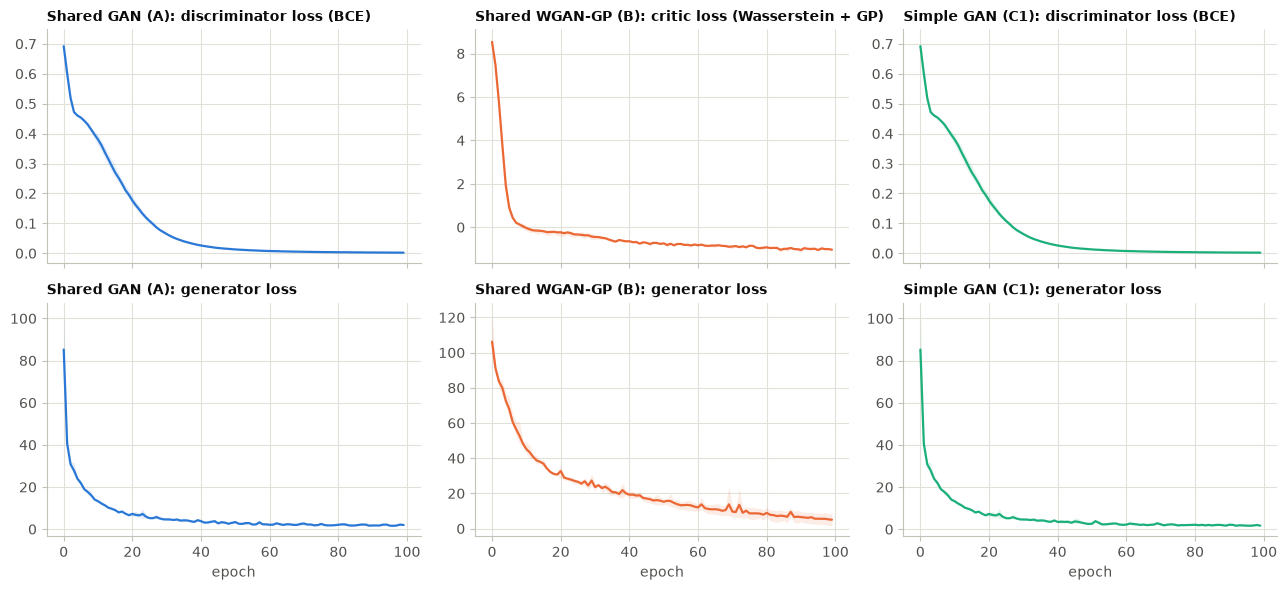

In [19]:
ADVERSARY = {"Shared GAN (A)": "discriminator loss (BCE)", "Shared WGAN-GP (B)": "critic loss (Wasserstein + GP)",
             "Simple GAN (C1)": "discriminator loss (BCE)"}
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for col, name in enumerate(IMPUTERS):
    hists = [h for _, h in runs[name].values()]
    for row, (key, what) in enumerate([("adv_loss", ADVERSARY[name]), ("g_loss", "generator loss")]):
        n_epochs = min(len(h[key]) for h in hists)
        plot_band(axes[row, col], np.array([h[key][:n_epochs] for h in hists]), COLORS[name])
        axes[row, col].set_title(f"{name}: {what}", fontsize=10)
    axes[1, col].set_xlabel("epoch")
fig.tight_layout()
save_fig(fig, "05_imputer_training_losses")

### 8.2 Test-period accuracy

All imputers are scored on the **same test blocks and the same removed entries**. One non-learned reference is added: **linear interpolation**, run within each block for each variable, using only that block's observed days. A learned imputer only earns its complexity if it beats this baseline.

Errors are measured **only at the removed entries**. Observed entries are copied through unchanged, so their error is zero by construction. Averaging over whole blocks would count those zeros and shrink every score by roughly $\sqrt{\text{missing fraction}}$, without saying anything about skill.

Metrics: temperature RMSE and MAE in °C (standardised errors multiplied by the training standard deviation), temperature $R^2$ over the removed entries, and all-variable RMSE and MAE in standardised units (the variables have different physical units). Values are mean ± standard deviation over the model seeds; ↓ marks metrics where lower is better, ↑ where higher is better.

In [20]:
BASELINE = -1   # "seed" label for the deterministic baselines


def linear_interpolation(x_in):
    """Non-learned baseline: per block and variable, interpolate removed days from that block's observed days."""
    obs, m = x_in[..., :N_FEATURES], x_in[..., N_FEATURES:]
    out, days = obs.copy(), np.arange(BLOCK_LEN)
    for b in range(len(obs)):
        for c in range(N_FEATURES):
            gap = m[b, :, c] == 1
            if gap.any() and (~gap).any():
                out[b, gap, c] = np.interp(days[gap], days[~gap], obs[b, ~gap, c])
    return out


def summarise(results, metrics, order):
    """Mean and standard deviation over seeds, and a "mean ± std" display table."""
    grouped = results.groupby("model", sort=False)[metrics]
    mean, std = grouped.mean().reindex(order), grouped.std(ddof=1).reindex(order)
    shown = pd.DataFrame(index=pd.Index(order, name="model"), columns=metrics, dtype=object)
    for col in metrics:
        shown[col] = [f"{m:.3f}" if not np.isfinite(s) else f"{m:.3f} ± {s:.3f}" for m, s in zip(mean[col], std[col])]
    return mean, std, shown


x_te, y_te = imp_data["test"]["x"], imp_data["test"]["y"]
test_recon = {name: {seed: impute(G, x_te) for seed, (G, _) in runs[name].items()} for name in IMPUTERS}
test_recon["Linear interpolation"] = {BASELINE: linear_interpolation(x_te)}

imp_results = pd.DataFrame([{"model": name, "seed": seed, **imputation_scores(x_hat, x_te, y_te)}
                            for name, recons in test_recon.items() for seed, x_hat in recons.items()])
IMP_METRICS = ["temp_RMSE_degC", "temp_MAE_degC", "temp_R2", "all_RMSE_scaled", "all_MAE_scaled"]
IMP_ORDER = IMPUTERS + ["Linear interpolation"]
IMP_HEADERS = {"temp_RMSE_degC": "Temp RMSE (°C) ↓", "temp_MAE_degC": "Temp MAE (°C) ↓", "temp_R2": "Temp R² ↑",
               "all_RMSE_scaled": "All-var RMSE (z) ↓", "all_MAE_scaled": "All-var MAE (z) ↓"}
imp_mean, imp_std, imp_table = summarise(imp_results, IMP_METRICS, IMP_ORDER)

imp_results.to_csv(OUT_DIR / "imputation_metrics_per_seed.csv", index=False)
pd.concat({"mean": imp_mean, "std": imp_std}, axis=1).to_csv(OUT_DIR / "imputation_metrics_summary.csv")
n_removed_temp = int(x_te[..., N_FEATURES + T_IDX].sum())
print(f"Test period {period_of(val_end, n_used - 1)}: {len(x_te)} blocks, {n_removed_temp:,} removed temperature "
      f"values, {int(x_te[..., N_FEATURES:].sum()):,} removed values in total; {len(SEEDS)} seed(s)")
display(imp_table.rename(columns=IMP_HEADERS))

Test period 2014-06-25 to 2025-12-23: 140 blocks, 702 removed temperature values, 4,479 removed values in total; 3 seed(s)


,Temp RMSE (°C) ↓,Temp MAE (°C) ↓,Temp R² ↑,All-var RMSE (z) ↓,All-var MAE (z) ↓
model,,,,,
Shared GAN (A),0.954 ± 0.066,0.729 ± 0.045,0.848 ± 0.021,0.831 ± 0.006,0.421 ± 0.001
Shared WGAN-GP (B),0.969 ± 0.058,0.745 ± 0.041,0.843 ± 0.019,0.832 ± 0.007,0.415 ± 0.007
Simple GAN (C1),0.904 ± 0.026,0.694 ± 0.015,0.864 ± 0.008,0.837 ± 0.005,0.431 ± 0.008
Linear interpolation,0.672,0.488,0.925,0.786,0.311


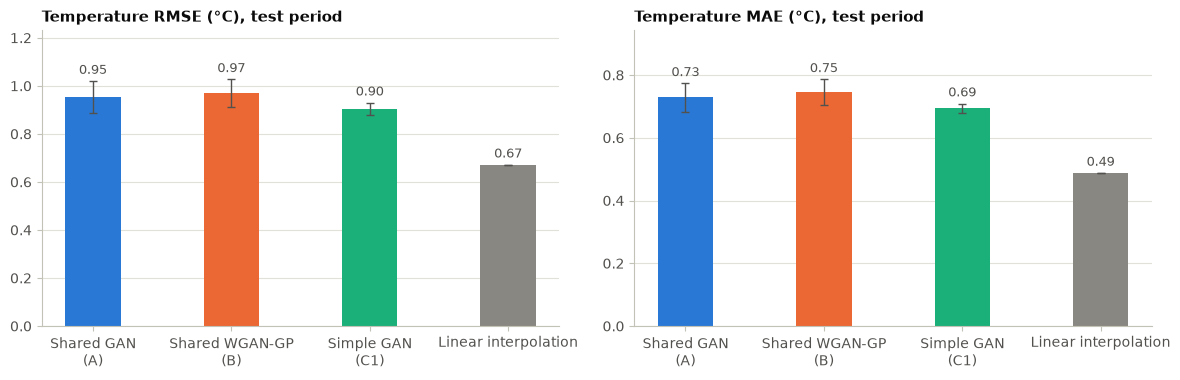

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))
for ax, (key, title) in zip(axes, [("temp_RMSE_degC", "Temperature RMSE (°C), test period"),
                                   ("temp_MAE_degC", "Temperature MAE (°C), test period")]):
    means, errs = imp_mean[key].values, np.nan_to_num(imp_std[key].values)
    ax.bar(range(len(IMP_ORDER)), means, yerr=errs if errs.any() else None, width=0.4,
           color=[COLORS[n] for n in IMP_ORDER], error_kw=dict(ecolor=INK_2, elinewidth=1, capsize=3))
    for i, (m, e) in enumerate(zip(means, errs)):
        ax.annotate(f"{m:.2f}", (i, m + e), xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, color=INK_2)
    ax.set_xticks(range(len(IMP_ORDER)), [n.replace(" (", "\n(") for n in IMP_ORDER])
    ax.set_ylim(0, (means + errs).max() * 1.2)
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
fig.tight_layout()
save_fig(fig, "06_imputation_test_accuracy")

### 8.3 Error by gap length

Isolated missing days are easy to fill from their neighbours; long gaps are not. Every removed temperature value is grouped by the length of the gap it sits in, measured inside its 30-day block, and the test RMSE (°C) is computed per group. This shows where adversarial training helps, if anywhere, relative to interpolation.

,Shared GAN (A),Shared WGAN-GP (B),Simple GAN (C1),Linear interpolation
gap length,,,,
1 day (n=303),0.807,0.814,0.788,0.475
2–3 days (n=83),0.889,0.874,0.825,0.852
4–6 days (n=106),1.161,1.199,1.070,0.782
7–10 days (n=182),1.090,1.113,1.024,0.778
11+ days (n=28),0.735,0.735,0.759,0.685


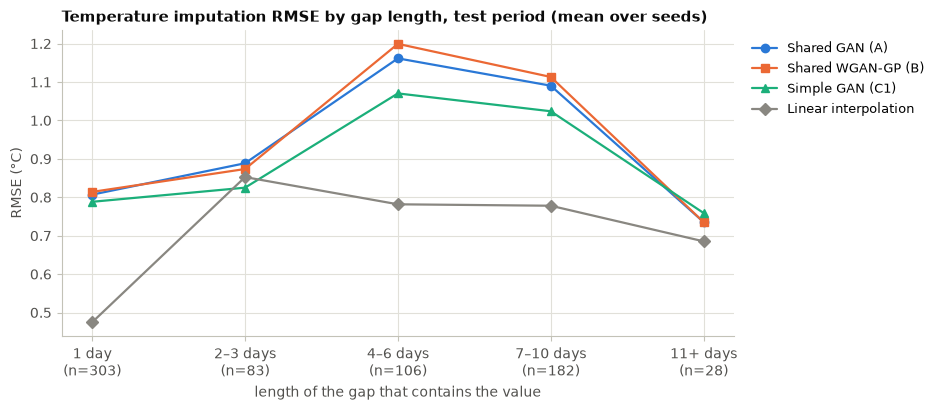

In [22]:
def run_lengths(missing):
    """Length of the contiguous run of removed days that each entry belongs to (0 = observed)."""
    lengths, t = np.zeros(len(missing), dtype=int), 0
    while t < len(missing):
        if missing[t]:
            start = t
            while t < len(missing) and missing[t]:
                t += 1
            lengths[start:t] = t - start
        else:
            t += 1
    return lengths


temp_missing = x_te[..., N_FEATURES + T_IDX].astype(bool)                   # (test blocks, 30)
gap_len = np.stack([run_lengths(row) for row in temp_missing])
GAP_BINS = [(1, 1, "1 day"), (2, 3, "2–3 days"), (4, 6, "4–6 days"), (7, 10, "7–10 days"), (11, BLOCK_LEN, "11+ days")]
bin_masks = [temp_missing & (gap_len >= lo) & (gap_len <= hi) for lo, hi, _ in GAP_BINS]
bin_labels = [f"{label}\n(n={int(b.sum())})" for (_, _, label), b in zip(GAP_BINS, bin_masks)]


def rmse_by_gap(x_hat):
    err = (x_hat[..., T_IDX] - y_te[..., T_IDX]) * TEMP_STD
    return [np.sqrt(np.mean(err[b] ** 2)) if b.any() else np.nan for b in bin_masks]


gap_table = pd.DataFrame({name: np.mean([rmse_by_gap(x_hat) for x_hat in recons.values()], axis=0)
                          for name, recons in test_recon.items()},
                         index=pd.Index([label.replace("\n", " ") for label in bin_labels], name="gap length"))
gap_table.to_csv(OUT_DIR / "imputation_temp_rmse_by_gap_length.csv")
display(gap_table.round(3))

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for name in IMP_ORDER:
    ax.plot(range(len(GAP_BINS)), gap_table[name].values, color=COLORS[name], marker=MARKERS[name], label=name)
ax.set_xticks(range(len(GAP_BINS)), bin_labels)
ax.set(title="Temperature imputation RMSE by gap length, test period (mean over seeds)",
       xlabel="length of the gap that contains the value", ylabel="RMSE (°C)")
legend_right(ax)
fig.tight_layout()
save_fig(fig, "07_imputation_error_by_gap_length")

### 8.4 Are the imputations shrunk toward the mean?

The table compares the imputed and true temperatures at the removed entries in three ways: the mean error (bias), the standard deviation of the imputed values, and the slope of a least-squares fit of imputed on true values. A standard deviation below the true one and a slope below 1 mean that the imputations are pulled toward the mean. Some shrinkage is expected from any imputer that minimises squared error: where the surrounding days say little about a missing value, the best guess lies close to the mean. A generative model, however, is meant to produce values as variable as real ones, so strong shrinkage in a GAN means that its adversarial term is not doing that job. The generators receive 0 at every missing entry, which after scaling is the training mean, so a generator that makes little use of the surrounding days stays close to that value.

In [23]:
def calibration(x_hat):
    """Bias, spread and slope of the imputed temperatures against the true ones (removed entries only)."""
    y_t, p_t = y_te[..., T_IDX][temp_missing], x_hat[..., T_IDX][temp_missing]
    return {"bias (°C)": (p_t - y_t).mean() * TEMP_STD,
            "std of imputed values (°C)": p_t.std() * TEMP_STD,
            "slope of imputed on true": np.polyfit(y_t, p_t, 1)[0]}


calib_table = pd.DataFrame({name: pd.DataFrame([calibration(x_hat) for x_hat in recons.values()]).mean()
                            for name, recons in test_recon.items()}).T
calib_table.index.name = "model"
calib_table.to_csv(OUT_DIR / "imputation_calibration.csv")
print(f"True temperatures at the removed entries: std {y_te[..., T_IDX][temp_missing].std() * TEMP_STD:.2f} °C. "
      "A perfect imputer has bias 0, the same std and slope 1 (mean over seeds).")
display(calib_table.round(3))

True temperatures at the removed entries: std 2.45 °C. A perfect imputer has bias 0, the same std and slope 1 (mean over seeds).


,bias (°C),std of imputed values (°C),slope of imputed on true
model,,,
Shared GAN (A),-0.194,2.042,0.776
Shared WGAN-GP (B),-0.243,1.977,0.753
Simple GAN (C1),-0.173,2.152,0.822
Linear interpolation,-0.100,2.406,0.945


### 8.5 Example test block

The test block with the most removed temperature days (first seed of each model). The black line is the true series; shaded days were removed, and the coloured markers show each model's reconstruction there.

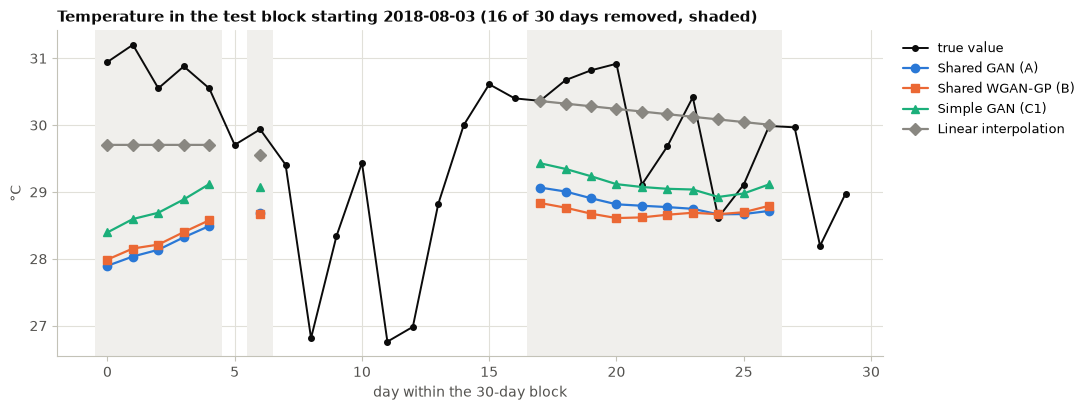

In [24]:
def to_degc(z):
    return z * TEMP_STD + TEMP_MEAN


b = int(np.argmax(temp_missing.sum(axis=1)))
gap = temp_missing[b]
days = np.arange(BLOCK_LEN)
block_start = df["date"].iloc[block_ids["test"][b] * BLOCK_LEN]

fig, ax = plt.subplots(figsize=(11, 4.2))
for d in days[gap]:
    ax.axvspan(d - 0.5, d + 0.5, color=WASH, lw=0)
ax.plot(days, to_degc(y_te[b, :, T_IDX]), color=INK, marker="o", ms=4, lw=1.4, label="true value")
for name in IMP_ORDER:
    recon = next(iter(test_recon[name].values()))
    ax.plot(days, np.where(gap, to_degc(recon[b, :, T_IDX]), np.nan), color=COLORS[name],
            marker=MARKERS[name], label=name)
ax.set(title=f"Temperature in the test block starting {block_start:%Y-%m-%d} "
             f"({int(gap.sum())} of {BLOCK_LEN} days removed, shaded)",
       xlabel="day within the 30-day block", ylabel="°C")
legend_right(ax)
fig.tight_layout()
save_fig(fig, "08_imputation_example_block")

## 9. Evaluation: forecasting

### 9.1 Training dynamics of the forecasting GAN (C2)

Validation forecast RMSE after every epoch, with the conditional discriminator's loss and the generator's loss on the training data (mean over seeds, seed range shaded; dots mark the kept checkpoints). The generator's training loss keeps falling, but its validation error is lowest after 5–10 epochs and then rises by about 30 %, a sign of overfitting to the training period. Checkpoint selection matters here too.

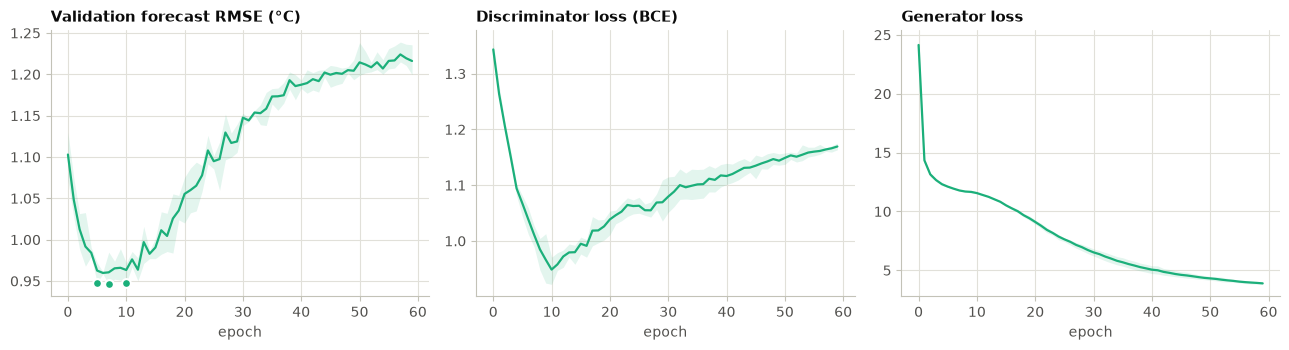

In [25]:
hists_c2 = [h for _, h in runs["Simple GAN (C2)"].values()]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
panels = [("Validation forecast RMSE (°C)", lambda h: [v["RMSE_degC"] for v in h["val"]]),
          ("Discriminator loss (BCE)", lambda h: h["adv_loss"]),
          ("Generator loss", lambda h: h["g_loss"])]
for ax, (title, series) in zip(axes, panels):
    n_epochs = min(len(series(h)) for h in hists_c2)
    plot_band(ax, np.array([series(h)[:n_epochs] for h in hists_c2]), COLORS["Simple GAN (C2)"])
    ax.set(title=title, xlabel="epoch")
kept = [(h["best_epoch"], h["val"][h["best_epoch"]]["RMSE_degC"]) for h in hists_c2]
axes[0].scatter(*zip(*kept), s=40, color=COLORS["Simple GAN (C2)"], edgecolor="white", linewidth=1.5, zorder=3)
fig.tight_layout()
save_fig(fig, "09_forecast_gan_training")

### 9.2 Test-period accuracy

Every forecaster predicts the **same 7-day temperature targets**: consecutive, non-overlapping weeks in the test period, each preceded by at least 30 test-period days of context.

* **Simple GAN (C2)** receives the previous 30 days of all six variables.
* **Shared GAN (A)** and **Shared WGAN-GP (B)** are used exactly as trained for imputation, with no forecasting-specific training. Each gets the 30-day block that ends on the last target day. The first 23 days are context, and the final 7 days are masked for **all** variables, because nothing about the future is known. Filling that trailing gap is a 7-day forecast. The shared generators never saw a trailing all-variable gap during training, so this measures how far their imputation training transfers to forecasting.
* **Persistence**, the standard naive baseline, repeats the last observed temperature for every lead day.

Scores: RMSE, MAE and $R^2$ in °C over all windows and lead days, plus the **skill score** $1 - \mathrm{RMSE}_{\text{model}} / \mathrm{RMSE}_{\text{persistence}}$ (positive = better than persistence).

**Forecasting from incomplete records.** Operational records have gaps too, so the evaluation is repeated with the injected missingness left in every context window. The shared generators take the gappy context directly. The task-specific pipeline first fills the context with C1, then forecasts with C2. Persistence falls back to the last *observed* temperature.

In [26]:
fc_te = fc_data["test"]
target_rows, y_fc = fc_te["target_rows"], fc_te["y"]       # first-forecast-day rows; true temperatures (z)
SHARED_CONTEXT = BLOCK_LEN - HORIZON                         # 23 context days + 7 masked days = one 30-day block
assert CONTEXT == BLOCK_LEN, "the C1 -> C2 pipeline imputes C2's context with the 30-day C1 generator"


def shared_forecast(G, gappy):
    """Forecast with a shared generator by masking the final HORIZON days of a 30-day block for every variable."""
    x = np.stack([scaled[r - SHARED_CONTEXT:r + HORIZON] for r in target_rows])
    m = np.zeros_like(x)
    m[:, SHARED_CONTEXT:, :] = 1.0                           # the future: all variables unknown
    if gappy:                                                # keep the injected gaps in the context days
        m[:, :SHARED_CONTEXT, :] = np.stack([miss[r - SHARED_CONTEXT:r] for r in target_rows])
    x_in = np.concatenate([x * (1.0 - m), m], axis=-1).astype(np.float32)
    return impute(G, x_in)[:, SHARED_CONTEXT:, T_IDX:T_IDX + 1]


def gappy_context_blocks():
    """C2's 30-day contexts with the injected gaps, as [zero-filled values | indicator] input for C1."""
    x = np.stack([scaled[r - CONTEXT:r] for r in target_rows])
    m = np.stack([miss[r - CONTEXT:r] for r in target_rows]).astype(np.float32)
    return np.concatenate([x * (1.0 - m), m], axis=-1)


def persistence(gappy):
    """Repeat the last (observed) temperature before the first forecast day for every lead day."""
    last = []
    for r in target_rows:
        rows = np.arange(r - CONTEXT, r)
        if gappy:
            rows = rows[~miss[rows, T_IDX]]
        last.append(scaled[rows[-1], T_IDX] if len(rows) else 0.0)
    return np.repeat(np.array(last, dtype=np.float32)[:, None, None], HORIZON, axis=1)


forecasts = {   # (setting, model) -> {seed: forecast in standardised units, shape (windows, HORIZON, 1)}
    ("complete context", "Persistence"): {BASELINE: persistence(gappy=False)},
    ("complete context", "Simple GAN (C2)"): {s: forecast_with_gan(Gf, fc_te["x"])
                                               for s, (Gf, _) in runs["Simple GAN (C2)"].items()},
    ("gappy context", "Persistence"): {BASELINE: persistence(gappy=True)},
    ("gappy context", "Simple GAN (C1 → C2)"): {
        s: forecast_with_gan(Gf, impute(runs["Simple GAN (C1)"][s][0], gappy_context_blocks()))
        for s, (Gf, _) in runs["Simple GAN (C2)"].items()},
}
for setting, gappy in (("complete context", False), ("gappy context", True)):
    for name in ["Shared GAN (A)", "Shared WGAN-GP (B)"]:
        forecasts[(setting, name)] = {s: shared_forecast(G, gappy) for s, (G, _) in runs[name].items()}

fc_results = pd.DataFrame([{"setting": setting, "model": name, "seed": seed, **forecast_scores(pred, y_fc)}
                           for (setting, name), preds in forecasts.items() for seed, pred in preds.items()])
persistence_rmse = fc_results[fc_results.model == "Persistence"].set_index("setting")["RMSE_degC"]
fc_results["skill_vs_persistence"] = 1.0 - fc_results["RMSE_degC"] / fc_results["setting"].map(persistence_rmse)

FC_METRICS = ["RMSE_degC", "MAE_degC", "R2", "skill_vs_persistence"]
FC_ORDER = {"complete context": ["Persistence", "Simple GAN (C2)", "Shared GAN (A)", "Shared WGAN-GP (B)"],
            "gappy context": ["Persistence", "Simple GAN (C1 → C2)", "Shared GAN (A)", "Shared WGAN-GP (B)"]}
FC_HEADERS = {"RMSE_degC": "RMSE (°C) ↓", "MAE_degC": "MAE (°C) ↓", "R2": "R² ↑",
              "skill_vs_persistence": "Skill vs persistence ↑"}
fc_summary = {}
for setting, order in FC_ORDER.items():
    fc_summary[setting] = summarise(fc_results[fc_results.setting == setting], FC_METRICS, order)
    print(f"{HORIZON}-day temperature forecasts, test period, {setting}: {len(target_rows)} windows, "
          f"{len(SEEDS)} seed(s)")
    display(fc_summary[setting][2].rename(columns=FC_HEADERS))

lead_rmse = {key: np.mean([np.sqrt(np.mean(((p - y_fc)[..., 0] * TEMP_STD) ** 2, axis=0)) for p in preds.values()],
                          axis=0)
             for key, preds in forecasts.items()}
fc_results.to_csv(OUT_DIR / "forecast_metrics_per_seed.csv", index=False)
fc_results.groupby(["setting", "model"], sort=False)[FC_METRICS].agg(["mean", "std"]).to_csv(
    OUT_DIR / "forecast_metrics_summary.csv")
pd.DataFrame({f"{name} | {setting}": v for (setting, name), v in lead_rmse.items()},
             index=pd.Index(np.arange(1, HORIZON + 1), name="lead day")).to_csv(OUT_DIR / "forecast_rmse_by_lead_day.csv")

7-day temperature forecasts, test period, complete context: 596 windows, 3 seed(s)


,RMSE (°C) ↓,MAE (°C) ↓,R² ↑,Skill vs persistence ↑
model,,,,
Persistence,1.124,0.830,0.790,0.000
Simple GAN (C2),0.928 ± 0.011,0.700 ± 0.006,0.857 ± 0.003,0.174 ± 0.010
Shared GAN (A),1.735 ± 0.114,1.411 ± 0.109,0.499 ± 0.067,-0.543 ± 0.102
Shared WGAN-GP (B),1.757 ± 0.233,1.432 ± 0.211,0.481 ± 0.135,-0.563 ± 0.207


7-day temperature forecasts, test period, gappy context: 596 windows, 3 seed(s)


,RMSE (°C) ↓,MAE (°C) ↓,R² ↑,Skill vs persistence ↑
model,,,,
Persistence,1.179,0.865,0.769,0.000
Simple GAN (C1 → C2),0.963 ± 0.016,0.731 ± 0.009,0.846 ± 0.005,0.183 ± 0.013
Shared GAN (A),1.820 ± 0.099,1.492 ± 0.090,0.449 ± 0.060,-0.544 ± 0.084
Shared WGAN-GP (B),1.836 ± 0.231,1.505 ± 0.208,0.434 ± 0.140,-0.557 ± 0.196


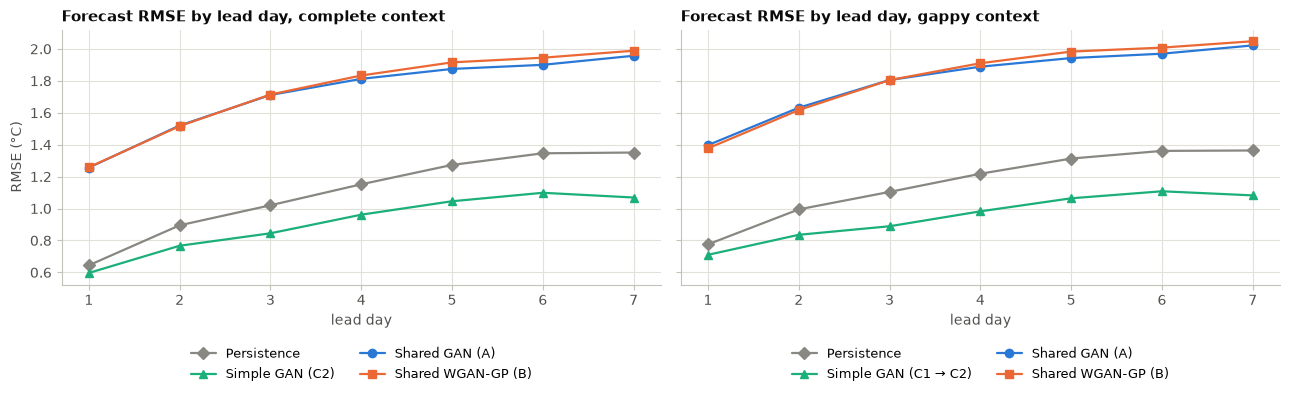

In [27]:
leads = np.arange(1, HORIZON + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, (setting, order) in zip(axes, FC_ORDER.items()):
    for name in order:
        ax.plot(leads, lead_rmse[(setting, name)], color=COLORS[name], marker=MARKERS[name], label=name)
    ax.set(title=f"Forecast RMSE by lead day, {setting}", xlabel="lead day", xticks=leads)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
axes[0].set_ylabel("RMSE (°C)")
fig.tight_layout()
save_fig(fig, "10_forecast_rmse_by_lead_day")

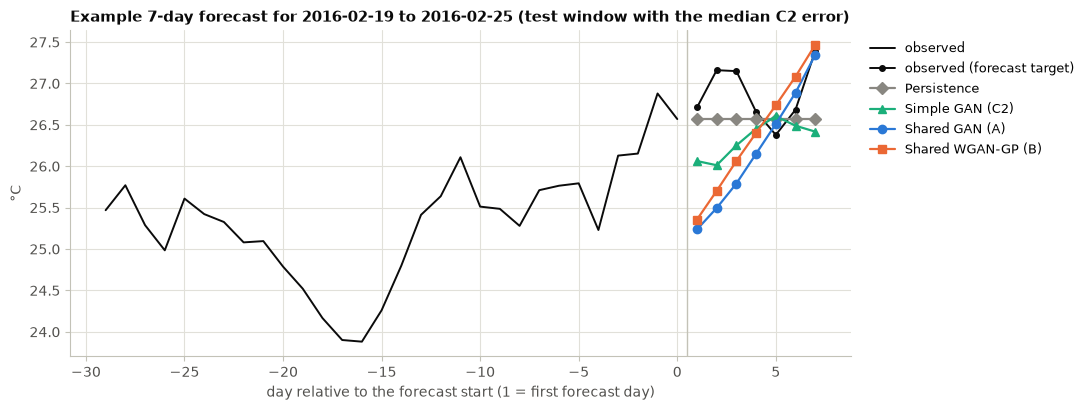

In [28]:
first_seed = SEEDS[0]
c2 = forecasts[("complete context", "Simple GAN (C2)")][first_seed]
window_rmse = np.sqrt(np.mean((c2 - y_fc)[..., 0] ** 2, axis=1))
k = int(np.argsort(window_rmse)[len(window_rmse) // 2])      # a representative window: median C2 error
r = target_rows[k]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axvline(0.5, color=AXIS, lw=1)
ax.plot(np.arange(-CONTEXT + 1, 1), to_degc(scaled[r - CONTEXT:r, T_IDX]), color=INK, lw=1.4, label="observed")
ax.plot(leads, to_degc(y_fc[k, :, 0]), color=INK, marker="o", ms=4, lw=1.4, label="observed (forecast target)")
for name in FC_ORDER["complete context"]:
    preds = forecasts[("complete context", name)]
    ax.plot(leads, to_degc(preds.get(first_seed, preds.get(BASELINE))[k, :, 0]), color=COLORS[name],
            marker=MARKERS[name], label=name)
ax.set(title=f"Example {HORIZON}-day forecast for {df['date'].iloc[r]:%Y-%m-%d} to "
             f"{df['date'].iloc[r + HORIZON - 1]:%Y-%m-%d} (test window with the median C2 error)",
       xlabel="day relative to the forecast start (1 = first forecast day)", ylabel="°C")
legend_right(ax)
fig.tight_layout()
save_fig(fig, "11_forecast_example")

## 10. Results summary

The cell below writes the headline numbers of this run into a short report and saves it to `outputs/results_summary.md`, together with every score, the configuration and the package versions in `outputs/run_summary.json`. Interpret the numbers with the caveats in Section 11.

In [29]:
def markdown_table(frame):
    header = "| " + " | ".join([frame.index.name or ""] + [str(c) for c in frame.columns]) + " |"
    rule = "|" + "---|" * (len(frame.columns) + 1)
    rows = ["| " + " | ".join([str(i)] + [str(v) for v in row]) + " |" for i, row in zip(frame.index, frame.values)]
    return "\n".join([header, rule] + rows)


def pm(mean, std):
    return f"{mean:.3f}" + (f" ± {std:.3f}" if np.isfinite(std) else "")


lines = []
if QUICK_TEST:
    lines.append("> **QUICK_TEST run: every model trained for 2 epochs only, so these numbers are not meaningful.**\n")
lin = imp_mean.loc["Linear interpolation", "temp_RMSE_degC"]
lines.append(f"**Imputation**, test period {period_of(val_end, n_used - 1)} ({n_removed_temp:,} removed temperature "
             f"values, mean ± std over {len(SEEDS)} seed(s)):\n")
for name in IMP_ORDER:
    m, s = imp_mean.loc[name, "temp_RMSE_degC"], imp_std.loc[name, "temp_RMSE_degC"]
    versus = "" if name == "Linear interpolation" else f"; {(m - lin) / lin:+.1%} vs linear interpolation"
    lines.append(f"- {name}: temperature RMSE {pm(m, s)} °C{versus}")
lines.append(f"- Lowest temperature RMSE: **{imp_mean['temp_RMSE_degC'].idxmin()}**\n")

for setting, (mean, std, _) in fc_summary.items():
    lines.append(f"**{HORIZON}-day forecasting, {setting}** ({len(target_rows)} test windows):\n")
    for name in FC_ORDER[setting]:
        skill = "" if name == "Persistence" else (
            f"; skill vs persistence {pm(mean.loc[name, 'skill_vs_persistence'], std.loc[name, 'skill_vs_persistence'])}")
        lines.append(f"- {name}: RMSE {pm(mean.loc[name, 'RMSE_degC'], std.loc[name, 'RMSE_degC'])} °C{skill}")
    lines.append("")

lines += ["### Imputation, test period", "", markdown_table(imp_table.rename(columns=IMP_HEADERS)), ""]
for setting in FC_ORDER:
    lines += [f"### {HORIZON}-day temperature forecasting, test period, {setting}", "",
              markdown_table(fc_summary[setting][2].rename(columns=FC_HEADERS)), ""]
summary_md = "\n".join(lines)
(OUT_DIR / "results_summary.md").write_text(summary_md, encoding="utf-8")
display(Markdown(summary_md))


def to_builtin(o):
    return o.item() if hasattr(o, "item") else str(o)


run_summary = {
    "quick_test": QUICK_TEST, "seeds": SEEDS, "mask_seed": MASK_SEED,
    "data": {"source": "ECMWF/ERA5_LAND/DAILY_AGGR (Google Earth Engine)", "lon": LON, "lat": LAT,
             "first_date": f"{df['date'].min():%Y-%m-%d}", "last_date": f"{df['date'].max():%Y-%m-%d}", "days": n_rows},
    "benchmark": {"block_len": BLOCK_LEN, "blocks": {k: len(v) for k, v in block_ids.items()},
                  "periods": split_table["period"].to_dict(), "missingness": MISSINGNESS,
                  "injected_missing_rate": float(miss.mean()), "horizon": HORIZON,
                  "forecast_windows": {k: len(v["x"]) for k, v in fc_data.items()}},
    "hyperparameters": {"Shared GAN (A)": HP_SHARED_GAN, "Shared WGAN-GP (B)": HP_SHARED_WGAN,
                        "Simple GAN (C1)": HP_SIMPLE_IMP, "Simple GAN (C2)": HP_SIMPLE_FC},
    "best_epochs": {name: {str(s): h["best_epoch"] for s, (_, h) in seeds.items()} for name, seeds in runs.items()},
    "training_minutes": {name: round(sum(h["seconds"] for _, h in seeds.values()) / 60, 2)
                         for name, seeds in runs.items()},
    "imputation_test": imp_results.to_dict(orient="records"),
    "forecast_test": fc_results.to_dict(orient="records"),
    "environment": {"python": platform.python_version(), "tensorflow": tf.__version__, "numpy": np.__version__,
                    "pandas": pd.__version__, "scikit-learn": sklearn.__version__, "gpu": [g.name for g in gpus]},
}
(OUT_DIR / "run_summary.json").write_text(json.dumps(run_summary, indent=2, default=to_builtin), encoding="utf-8")
print(f"Wrote {OUT_DIR / 'results_summary.md'} and {OUT_DIR / 'run_summary.json'}; "
      f"total notebook runtime {(time.time() - NOTEBOOK_START) / 60:.1f} min")

**Imputation**, test period 2014-06-25 to 2025-12-23 (702 removed temperature values, mean ± std over 3 seed(s)):

- Shared GAN (A): temperature RMSE 0.954 ± 0.066 °C; +42.0% vs linear interpolation
- Shared WGAN-GP (B): temperature RMSE 0.969 ± 0.058 °C; +44.3% vs linear interpolation
- Simple GAN (C1): temperature RMSE 0.904 ± 0.026 °C; +34.6% vs linear interpolation
- Linear interpolation: temperature RMSE 0.672 °C
- Lowest temperature RMSE: **Linear interpolation**

**7-day forecasting, complete context** (596 test windows):

- Persistence: RMSE 1.124 °C
- Simple GAN (C2): RMSE 0.928 ± 0.011 °C; skill vs persistence 0.174 ± 0.010
- Shared GAN (A): RMSE 1.735 ± 0.114 °C; skill vs persistence -0.543 ± 0.102
- Shared WGAN-GP (B): RMSE 1.757 ± 0.233 °C; skill vs persistence -0.563 ± 0.207

**7-day forecasting, gappy context** (596 test windows):

- Persistence: RMSE 1.179 °C
- Simple GAN (C1 → C2): RMSE 0.963 ± 0.016 °C; skill vs persistence 0.183 ± 0.013
- Shared GAN (A): RMSE 1.820 ± 0.099 °C; skill vs persistence -0.544 ± 0.084
- Shared WGAN-GP (B): RMSE 1.836 ± 0.231 °C; skill vs persistence -0.557 ± 0.196

### Imputation, test period

| model | Temp RMSE (°C) ↓ | Temp MAE (°C) ↓ | Temp R² ↑ | All-var RMSE (z) ↓ | All-var MAE (z) ↓ |
|---|---|---|---|---|---|
| Shared GAN (A) | 0.954 ± 0.066 | 0.729 ± 0.045 | 0.848 ± 0.021 | 0.831 ± 0.006 | 0.421 ± 0.001 |
| Shared WGAN-GP (B) | 0.969 ± 0.058 | 0.745 ± 0.041 | 0.843 ± 0.019 | 0.832 ± 0.007 | 0.415 ± 0.007 |
| Simple GAN (C1) | 0.904 ± 0.026 | 0.694 ± 0.015 | 0.864 ± 0.008 | 0.837 ± 0.005 | 0.431 ± 0.008 |
| Linear interpolation | 0.672 | 0.488 | 0.925 | 0.786 | 0.311 |

### 7-day temperature forecasting, test period, complete context

| model | RMSE (°C) ↓ | MAE (°C) ↓ | R² ↑ | Skill vs persistence ↑ |
|---|---|---|---|---|
| Persistence | 1.124 | 0.830 | 0.790 | 0.000 |
| Simple GAN (C2) | 0.928 ± 0.011 | 0.700 ± 0.006 | 0.857 ± 0.003 | 0.174 ± 0.010 |
| Shared GAN (A) | 1.735 ± 0.114 | 1.411 ± 0.109 | 0.499 ± 0.067 | -0.543 ± 0.102 |
| Shared WGAN-GP (B) | 1.757 ± 0.233 | 1.432 ± 0.211 | 0.481 ± 0.135 | -0.563 ± 0.207 |

### 7-day temperature forecasting, test period, gappy context

| model | RMSE (°C) ↓ | MAE (°C) ↓ | R² ↑ | Skill vs persistence ↑ |
|---|---|---|---|---|
| Persistence | 1.179 | 0.865 | 0.769 | 0.000 |
| Simple GAN (C1 → C2) | 0.963 ± 0.016 | 0.731 ± 0.009 | 0.846 ± 0.005 | 0.183 ± 0.013 |
| Shared GAN (A) | 1.820 ± 0.099 | 1.492 ± 0.090 | 0.449 ± 0.060 | -0.544 ± 0.084 |
| Shared WGAN-GP (B) | 1.836 ± 0.231 | 1.505 ± 0.208 | 0.434 ± 0.140 | -0.557 ± 0.196 |


Wrote outputs/results_summary.md and outputs/run_summary.json; total notebook runtime 55.2 min


### Key findings

The numbers come from the run shown in this notebook (real ERA5-Land data, 3 seeds, test period 2014–2025) and match the tables above.

1. **No GAN imputer beats linear interpolation overall.** On the test period, temperature RMSE is 0.90–0.97 °C for the three GAN imputers against 0.67 °C for linear interpolation within each block. Interpolation is better at every gap length except 2–3 days, where C1 is marginally ahead (0.82 vs. 0.85 °C; Section 8.3). The GAN imputations are also smoother than the true values: their standard deviation is 1.98–2.15 °C against 2.45 °C, and the slope of imputed on true values is 0.75–0.82. Interpolation keeps almost all of the variability (2.41 °C, slope 0.95; Section 8.4).
2. **GAN and WGAN-GP reach the same accuracy but train very differently.** Their test errors overlap within one seed standard deviation (0.954 ± 0.066 vs. 0.969 ± 0.058 °C). The GAIN-style GAN is best after 6–12 epochs; by the last epoch its validation error (all variables) is about 40 % higher, as its discriminator saturates. The WGAN-GP improves for about 50 epochs and then rises by only 3–5 % (Section 8.1).
3. **Selecting checkpoints on temperature gives a small, uncertain gain.** C1, the same GAN as A but with checkpoints selected on temperature, reaches 0.904 ± 0.026 °C against 0.954 ± 0.066 °C for A. The difference is within the seed-to-seed spread.
4. **The conditional forecasting GAN (C2) beats persistence at every lead day.** Its RMSE is 0.928 ± 0.011 °C against 1.124 °C for persistence (skill +0.17), from 0.60 vs. 0.64 °C on day 1 to 1.07 vs. 1.35 °C on day 7. With gaps in the input history, the C1 → C2 pipeline keeps its advantage: 0.963 vs. 1.179 °C (skill +0.18).
5. **The shared generators do not forecast.** Asked to fill a trailing 7-day gap, Models A and B are far worse than persistence (skill −0.54 and −0.56), already on the first forecast day (RMSE 1.26 vs. 0.64 °C). Imputation training alone does not transfer to forecasting (Section 11).

## 11. Discussion and limitations

**Reading the comparisons**
* **A vs. B isolates the adversarial objective.** Generator, data, masks, reconstruction weight and checkpoint rule are identical. The only differences are the adversary (point-wise binary cross-entropy discriminator vs. block-level Wasserstein critic) and the optimiser settings and critic schedule each objective requires.
* **A vs. C1 changes no learning objective.** They differ only in the LSTM kernel implementation and the checkpoint criterion (all-variable vs. temperature RMSE). Their gap therefore measures checkpoint selection and seed-to-seed variability, not a better model; compare it with the ± spread before drawing conclusions.
* **Baselines set the bar.** A learned imputer is useful only if it beats linear interpolation, particularly on long gaps (Section 8.3), where interpolation has little to work with. A forecaster is useful only if its skill against persistence is positive.

**Why the GAN imputers lose to interpolation.** In the GAIN-style models (A and C1) the discriminator receives the full observation mask as its hint, so it can learn to reproduce the hint without looking at the values. Its loss falls from about 0.7 to 0.002 over the 100 epochs (Section 8.1), which is consistent with that. Once the discriminator ignores the values, the adversarial term no longer tells the generator anything about them, and the generator is in effect trained by the reconstruction term alone. That term covers **observed** entries only, where the input already holds the answer, so nothing trains the generator to fill the *missing* entries well. Validation error is therefore lowest after 6–14 epochs. By the last epoch it is about 40 % higher for A (all variables) and about twice as high for C1 (temperature), so selecting the best checkpoint is essential. Even the selected checkpoints use the neighbouring days less well than interpolation does (temperature R² 0.84–0.86 against 0.92), and their imputations are smoother than the true values (Section 8.4), the opposite of what an adversarial loss is meant to achieve. The Wasserstein critic (B) scores whole blocks, never sees the mask, and keeps supplying a gradient, so after its best epoch (around epoch 53) its validation error rises by only 3–5 %. It still reaches no better accuracy than A because, like A, it has no loss term that compares the filled-in values with the true ones.

Two standard remedies follow. The first is GAIN's *hint mechanism* (Yoon et al., 2018), which reveals only a random subset of the mask to the discriminator, so it has to judge the values themselves. The second targets the root cause directly: masked-reconstruction training. At every step, also hide a random share of the *observed* values and reconstruct them, so the generator is supervised on exactly the task it performs at test time (as in the masked imputation task of SAITS; Du et al., 2023).

**Information available to each model.** The WGAN-GP critic uses complete training blocks as its real examples, including the true values at the removed training entries. That is legitimate here: ERA5-Land is gap-free, and in practice complete historical periods exist to learn from. It does give Model B information that Models A and C1 never use. Test-time inputs are identical for all models.

**Shared generators as forecasters.** Models A and B were trained only with scattered and block gaps, never with a gap covering every variable at the end of a window. Their forecasting scores therefore measure how far imputation training transfers to forecasting, from a 23-day context rather than C2's 30 days. Here it does not transfer: their skill against persistence is about −0.55. A genuinely shared imputation-and-forecasting generator would mix trailing gaps into the training masks (masked-modelling style); that is the natural next step for this framework. Only a generator trained that way can deliver the practical promise of the shared design, forecasting directly from gappy records without a separate imputation stage. In this study the task-specific pipeline (C1 → C2) kept its skill on gappy records (+0.18).

**Further limitations**
* *Non-stationarity.* The test period is the most recent part of the record, so any warming moves it away from the training distribution. At this grid cell the trend is weak (+0.03 °C per decade, Section 2) and the shift is small, but that need not hold at other sites. Chronological evaluation keeps this effect visible instead of hiding it, as a random split would.
* *Synthetic missingness.* Values are removed at random or in random runs. Real outages can depend on the weather itself (e.g. during storms), which is harder and not tested here.
* *Uncertainty.* The seeds vary initialisation and batch order, but the split and the missingness pattern are fixed. Differences smaller than the seed-to-seed spread should not be read as real. Formal claims need paired tests on per-window errors (e.g. Diebold & Mariano, 1995) or block-bootstrap confidence intervals.
* *Scope.* One ERA5-Land grid cell (Chennai) and point-error metrics only. The generative side of the models is not evaluated: sampling $z$ for probabilistic forecasts scored with CRPS, and behaviour during extreme events.

## 12. Reproducibility and references

**Reproducing the results**
* All randomness is seeded (`SEEDS` for the models, `MASK_SEED` for the missingness). The results shown were computed on a CPU with TensorFlow 2.21, and two complete runs gave identical numbers. On a GPU, cuDNN kernels are not bit-for-bit deterministic, so repeated runs can differ slightly; this is one reason results are averaged over seeds. For exact repeatability, add `tf.config.experimental.enable_op_determinism()` after the imports; training becomes slower.
* Everything the notebook produces is written to `outputs/`:

| File | Content |
|---|---|
| `imputation_metrics_per_seed.csv`, `imputation_metrics_summary.csv` | test-period imputation scores |
| `imputation_temp_rmse_by_gap_length.csv` | temperature imputation RMSE by gap length |
| `imputation_calibration.csv` | bias, spread and slope of the imputed temperatures |
| `forecast_metrics_per_seed.csv`, `forecast_metrics_summary.csv`, `forecast_rmse_by_lead_day.csv` | test-period forecast scores |
| `results_summary.md` | the Section 10 summary, ready to paste into the README |
| `run_summary.json` | configuration, data span, selected epochs, runtimes, all scores and package versions |
| `figures/*.png` | every figure, at 200 dpi |
| `models/*.weights.h5` | trained generator weights; rebuild with the same builder function, then `load_weights(...)` |

* In Colab, files under `/content` are deleted when the runtime is recycled. Download `outputs/` and `data/`, or copy them to Google Drive, before closing the session.

**References**
1. Muñoz-Sabater, J. et al. (2021). ERA5-Land: a state-of-the-art global reanalysis dataset for land applications. *Earth System Science Data*, 13, 4349–4383.
2. Hersbach, H. et al. (2020). The ERA5 global reanalysis. *Quarterly Journal of the Royal Meteorological Society*, 146, 1999–2049.
3. Gorelick, N. et al. (2017). Google Earth Engine: planetary-scale geospatial analysis for everyone. *Remote Sensing of Environment*, 202, 18–27.
4. Wu, Q. (2020). geemap: a Python package for interactive mapping with Google Earth Engine. *Journal of Open Source Software*, 5(51), 2305.
5. Goodfellow, I. et al. (2014). Generative adversarial nets. *Advances in Neural Information Processing Systems*, 27.
6. Mirza, M. & Osindero, S. (2014). Conditional generative adversarial nets. arXiv:1411.1784.
7. Yoon, J., Jordon, J. & van der Schaar, M. (2018). GAIN: missing data imputation using generative adversarial nets. *Proceedings of the 35th International Conference on Machine Learning*, PMLR 80, 5689–5698.
8. Arjovsky, M., Chintala, S. & Bottou, L. (2017). Wasserstein generative adversarial networks. *Proceedings of the 34th International Conference on Machine Learning*, PMLR 70, 214–223.
9. Gulrajani, I., Ahmed, F., Arjovsky, M., Dumoulin, V. & Courville, A. (2017). Improved training of Wasserstein GANs. *Advances in Neural Information Processing Systems*, 30.
10. Luo, Y., Cai, X., Zhang, Y., Xu, J. & Yuan, X. (2018). Multivariate time series imputation with generative adversarial networks. *Advances in Neural Information Processing Systems*, 31.
11. Koochali, A., Schichtel, P., Dengel, A. & Ahmed, S. (2019). Probabilistic forecasting of sensory data with generative adversarial networks – ForGAN. *IEEE Access*, 7, 63868–63880.
12. Hochreiter, S. & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735–1780.
13. Diebold, F. X. & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263.
14. Du, W., Côté, D. & Liu, Y. (2023). SAITS: self-attention-based imputation for time series. *Expert Systems with Applications*, 219, 119619.